# Trabalho Principal Consolidado

Partes 1 a 4, em ordem, sem misturar com análises complementares.

## Estrutura

1. `trabalho_parte_1.ipynb`
2. `trabalho_parte_2.ipynb`
3. `trabalho_parte_3.ipynb`
4. `trabalho_parte_4.ipynb`


---

# Seção: `trabalho_parte_1.ipynb`

Origem: `ia_tech_challenge_01/trabalho_parte_1.ipynb`

### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs
#### Parte 1 - Dados Gerais - Redução do volume da base de dados

Fonte de dados escolhida: DATASUS  
Tipo de dados de origem: DBC

* Foram obtidos no site do SUS os dados de SIH/SUS - Sistema de Informações Hospitalares, arquivo RD - AIH Reduzida, do estado do Rio de Janeiro no ano de 2025.
* Os dados originais são disponibilizados em formato DBC e divididos por mês, com isso foi necessário:
    * Descompactá-los para o formato DBF
    * Realizar a conversão para o formato Parquet
        - Arquivos parquet conseguem otimizar o volume de dados facilitando seu tamanho e manipulação
    * Realizar o merge mês a mês para gerar o arquivo referente ao ano de 2025
    * O resultado foi o arquivo 2025_consolidado.parquet
    * Todas as ações anteriores não foram documentadas passo a passo aqui, pois não fazem parte do escopo geral da apresentação

---

## Sumário da Parte 1

**Objetivo geral - Redução do volume de dados**

Organizar a base SIH/SUS RD de 2025, avaliar sua estrutura inicial, manter apenas as colunas relevantes ao recorte analítico e gerar uma versão reduzida em Parquet para as próximas etapas de tratamento.

**Item 1 - Leitura estrutural da base consolidada**

- **1.1 - Carregamento e amostra inicial**
- **1.2 - Descrição estatística da base**
- **1.3 - Dimensões da base consolidada**
- **1.4 - Tipos de dados e uso de memória**

**Item 2 - Dicionário de Dados - SIH/SUS RD - AIH Reduzida**

- **2.1 - Consulta das colunas originais**
- **2.2 - Entendimento semântico dos campos**

**Item 3 - Remoção de colunas não utilizadas**

- **3.1 - Definição das colunas mantidas**
- **3.2 - Registro das colunas removidas**
- **3.3 - Geração da base reduzida**

**Item 4 - Validação da base reduzida**

- **4.1 - Conferência das colunas finais**
- **4.2 - Conferência do shape final**


#### Item 1 - Leitura estrutural da base consolidada

**Neste passo vamos:**

- **1.1 - Carregar e visualizar uma amostra da base consolidada** para confirmar que o arquivo `2025_consolidado.parquet` foi lido corretamente.
- **1.2 - Avaliar a descrição estatística geral** para observar distribuições, valores frequentes e comportamento inicial das colunas.
- **1.3 - Conferir as dimensões da base** para registrar quantidade de linhas e colunas antes da redução.
- **1.4 - Avaliar tipos de dados e uso de memória** para entender a estrutura inicial antes de selecionar colunas.


##### 1.1 - Carregamento e amostra inicial

Leitura do arquivo consolidado de 2025 e visualização das primeiras linhas para validar a estrutura carregada.


In [1]:
import pandas as pd

dados = pd.read_parquet('2025_consolidado.parquet')
dados.head()

,UF_ZI,ANO_CMPT,MES_CMPT,ESPEC,CGC_HOSP,N_AIH,IDENT,CEP,MUNIC_RES,NASC,...,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,FONTE_ORC
0,330000,2025,01,07,,3324112102003,1,23066260,330455,20150219,...,0,0,0,0,0,0,0,0,0,NaN
1,330000,2025,01,07,,3324112102014,1,25070512,330170,20180804,...,0,0,0,0,0,0,0,0,0,NaN
2,330000,2025,01,03,42498717001046,3324108710329,1,25241390,330170,19670412,...,0,0,0,0,0,0,0,0,0,NaN
3,330000,2025,01,03,42498717001046,3324108710340,1,26195340,330045,19640923,...,2,0,0,0,0,0,0,0,0,NaN
4,330000,2025,01,03,42498717001046,3324108710351,1,27265550,330630,20040414,...,0,0,0,0,0,0,0,0,0,NaN


##### 1.2 - Descrição estatística da base

Avaliação geral das colunas numéricas e categóricas para entender valores, frequências e possíveis inconsistências iniciais.


In [2]:
dados.describe(include='all')

,UF_ZI,ANO_CMPT,MES_CMPT,ESPEC,CGC_HOSP,N_AIH,IDENT,CEP,MUNIC_RES,NASC,...,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,FONTE_ORC
count,925240,925240,925240,925240,925240,925240,925240,925240,925240,925240,...,925240,925240,925240,925240,925240,925240,925240,925240,925240,777636
unique,83,1,12,13,176,918108,2,73321,827,36373,...,3,3,3,3,3,3,3,3,3,1
top,330455,2025,10,01,,3324106423297,1,28010000,330455,20250313,...,0,0,0,0,0,0,0,0,0,00
freq,284050,925240,80926,335867,264992,13,917577,12616,288172,184,...,722288,891839,909121,917761,922036,923862,924726,925100,925196,777636
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### 1.3 - Dimensões da base consolidada

Registro do volume original antes da remoção de colunas.


In [3]:
dados.shape

(925240, 114)

##### 1.4 - Tipos de dados e uso de memória

Verificação dos tipos inferidos para cada coluna, quantidade de valores não nulos e uso aproximado de memória.


In [4]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 925240 entries, 0 to 925239
Columns: 114 entries, UF_ZI to FONTE_ORC
dtypes: float64(19), int64(17), str(78)
memory usage: 1.0 GB


#### Item 2 - Dicionário de Dados - SIH/SUS RD - AIH Reduzida

**Neste passo vamos consultar o dicionário original para entender o significado das colunas antes da redução.**


| Ordem | Coluna | Descrição |
|---:|---|---|
| 1 | UF_ZI | Município gestor da internação, conforme codificação IBGE/DATASUS. |
| 2 | ANO_CMPT | Ano de competência/processamento da informação, no formato aaaa. |
| 3 | MES_CMPT | Mês de competência/processamento da informação, no formato mm. |
| 4 | ESPEC | Código da especialidade associada a AIH/internação. |
| 5 | CGC_HOSP | CNPJ/CGC do estabelecimento hospitalar. |
| 6 | N_AIH | Número da Autorização de Internacao Hospitalar (AIH). |
| 7 | IDENT | Identificacao do tipo de AIH. |
| 8 | CEP | CEP de residência do paciente. |
| 9 | MUNIC_RES | Código IBGE do município de residência do paciente. |
| 10 | NASC | Data de nascimento do paciente, no formato aaaammdd. |
| 11 | SEXO | Sexo do paciente: 1 masculino; 3 feminino. |
| 12 | UTI_MES_IN | Quantidade de dias de UTI no mês inicial da internação. |
| 13 | UTI_MES_AN | Quantidade de dias de UTI em mês anterior ao mes da alta. |
| 14 | UTI_MES_AL | Quantidade de dias de UTI no mês da alta. |
| 15 | UTI_MES_TO | Quantidade total de dias/atos de UTI. |
| 16 | MARCA_UTI | Marcador/tipo de UTI associado ao ato informado. |
| 17 | UTI_INT_IN | Dias em unidade intermediaria no mês inicial da internação. |
| 18 | UTI_INT_AN | Dias em unidade intermediaria em mês anterior ao mes da alta. |
| 19 | UTI_INT_AL | Dias em unidade intermediaria no mês da alta. |
| 20 | UTI_INT_TO | Total de dias em unidade intermediaria. |
| 21 | DIAR_ACOM | Quantidade de diarias de acompanhante. |
| 22 | QT_DIARIAS | Quantidade de diarias da internação. |
| 23 | PROC_SOLIC | Código do procedimento solicitado. |
| 24 | PROC_REA | Código do procedimento realizado. |
| 25 | VAL_SH | Valor dos serviços hospitalares. |
| 26 | VAL_SP | Valor dos serviços profissionais/prestados por terceiros. |
| 27 | VAL_SADT | Valor de serviços auxiliares de diagnóstico e terapia (SADT). |
| 28 | VAL_RN | Valor referente a recém-nato. |
| 29 | VAL_ACOMP | Valor referente a acompanhante. |
| 30 | VAL_ORTP | Valor de órtese e prótese. |
| 31 | VAL_SANGUE | Valor referente a sangue/hemoderivados. |
| 32 | VAL_SADTSR | Valor de SADT sem rateio. |
| 33 | VAL_TRANSP | Valor referente a transplante. |
| 34 | VAL_OBSANG | Valor referente a observação/anestesia ou sangue, conforme layout SIH. |
| 35 | VAL_PED1AC | Valor referente a pediatria/primeiro acompanhante, conforme layout SIH. |
| 36 | VAL_TOT | Valor total aprovado/pago da AIH. |
| 37 | VAL_UTI | Valor referente a UTI. |
| 38 | US_TOT | Valor total em dólar. |
| 39 | DT_INTER | Data da internação, no formato aaaammdd. |
| 40 | DT_SAIDA | Data da saída/alta, no formato aaaammdd. |
| 41 | DIAG_PRINC | Diagnostico principal informado, em código CID. |
| 42 | DIAG_SECUN | Diagnostico secundário informado, em código CID. |
| 43 | COBRANCA | Motivo de cobrança/saída/permanência da AIH. |
| 44 | NATUREZA | Natureza jurídica do hospital no layout legado. |
| 45 | NAT_JUR | Natureza jurídica do estabelecimento. |
| 46 | GESTAO | Tipo/código de gestão ou órgão emissor do gestor. |
| 47 | RUBRICA | Número da rubrica. |
| 48 | IND_VDRL | Indicador de exame VDRL. |
| 49 | MUNIC_MOV | Código IBGE do município do estabelecimento onde ocorreu a internação. |
| 50 | COD_IDADE | Unidade de medida usada para interpretar a idade. |
| 51 | IDADE | Idade do paciente conforme a unidade indicada em COD_IDADE. |
| 52 | DIAS_PERM | Quantidade de dias de permanência. |
| 53 | MORTE | Indicador de óbito. |
| 54 | NACIONAL | Código da nacionalidade do paciente. |
| 55 | NUM_PROC | Número do processamento. |
| 56 | CAR_INT | Carater da internação. |
| 57 | TOT_PT_SP | Total de pontos em serviços profissionais. |
| 58 | CPF_AUT | CPF do auditor/autorizador. |
| 59 | HOMONIMO | Indicador de homonímia do paciente. |
| 60 | NUM_FILHOS | Quantidade de filhos do paciente. |
| 61 | INSTRU | Grau de instrução do paciente. |
| 62 | CID_NOTIF | CID de notificação. |
| 63 | CONTRACEP1 | Metodo contraceptivo informado no campo 1. |
| 64 | CONTRACEP2 | Metodo contraceptivo informado no campo 2. |
| 65 | GESTRISCO | Indicador de gestante de alto risco. |
| 66 | INSC_PN | Número da gestante no pré-natal. |
| 67 | SEQ_AIH5 | Sequencial da AIH tipo 5, usada em longa permanência. |
| 68 | CBOR | Código da ocupação/CBO. |
| 69 | CNAER | Código de acidente de trabalho. |
| 70 | VINCPREV | Vínculo com a previdência. |
| 71 | GESTOR_COD | Motivo/código de autorização da AIH pelo gestor. |
| 72 | GESTOR_TP | Tipo de gestor. |
| 73 | GESTOR_CPF | CPF do gestor/autorizador. |
| 74 | GESTOR_DT | Data da autorização dada pelo gestor, no formato aaaammdd. |
| 75 | CNES | Código CNES do estabelecimento de saúde. |
| 76 | CNPJ_MANT | CNPJ da mantenedora do estabelecimento. |
| 77 | INFEHOSP | Indicador/status de infecção hospitalar. |
| 78 | CID_ASSO | CID associado/causa. |
| 79 | CID_MORTE | CID associado ao óbito. |
| 80 | COMPLEX | Complexidade do procedimento/internação. |
| 81 | FINANC | Tipo de financiamento. |
| 82 | FAEC_TP | Subtipo de financiamento FAEC. |
| 83 | REGCT | Regra contratual. |
| 84 | RACA_COR | Raca/cor do paciente. |
| 85 | ETNIA | Etnia do paciente, quando aplicavel. |
| 86 | SEQUENCIA | Sequencial da AIH na remessa. |
| 87 | REMESSA | Número/identificacao da remessa. |
| 88 | AUD_JUST | Justificativa do auditor para aceitacao da AIH sem Cartao Nacional de Saude. |
| 89 | SIS_JUST | Justificativa do estabelecimento/sistema para aceitacao da AIH sem Cartao Nacional de Saude. |
| 90 | VAL_SH_FED | Valor do complemento federal de serviços hospitalares, incluido no total da AIH. |
| 91 | VAL_SP_FED | Valor do complemento federal de serviços profissionais, incluido no total da AIH. |
| 92 | VAL_SH_GES | Valor do complemento do gestor para serviços hospitalares, incluido no total da AIH. |
| 93 | VAL_SP_GES | Valor do complemento do gestor para serviços profissionais, incluido no total da AIH. |
| 94 | VAL_UCI | Valor referente a unidade de cuidados intermediarios (UCI). |
| 95 | MARCA_UCI | Marcador/tipo de unidade de cuidados intermediarios (UCI). |
| 96 | DIAGSEC1 | Diagnostico secundário 1, em código CID. |
| 97 | DIAGSEC2 | Diagnostico secundário 2, em código CID. |
| 98 | DIAGSEC3 | Diagnostico secundário 3, em código CID. |
| 99 | DIAGSEC4 | Diagnostico secundário 4, em código CID. |
| 100 | DIAGSEC5 | Diagnostico secundário 5, em código CID. |
| 101 | DIAGSEC6 | Diagnostico secundário 6, em código CID. |
| 102 | DIAGSEC7 | Diagnostico secundário 7, em código CID. |
| 103 | DIAGSEC8 | Diagnostico secundário 8, em código CID. |
| 104 | DIAGSEC9 | Diagnostico secundário 9, em código CID. |
| 105 | TPDISEC1 | Tipo/classificacao do diagnóstico secundário 1. |
| 106 | TPDISEC2 | Tipo/classificacao do diagnóstico secundário 2. |
| 107 | TPDISEC3 | Tipo/classificacao do diagnóstico secundário 3. |
| 108 | TPDISEC4 | Tipo/classificacao do diagnóstico secundário 4. |
| 109 | TPDISEC5 | Tipo/classificacao do diagnóstico secundário 5. |
| 110 | TPDISEC6 | Tipo/classificacao do diagnóstico secundário 6. |
| 111 | TPDISEC7 | Tipo/classificacao do diagnóstico secundário 7. |
| 112 | TPDISEC8 | Tipo/classificacao do diagnóstico secundário 8. |
| 113 | TPDISEC9 | Tipo/classificacao do diagnóstico secundário 9. |
| 114 | FONTE_ORC | Fonte orçamentária associada ao registro. |


#### Item 3 - Remoção de colunas não utilizadas

Nesta etapa vamos manter apenas as colunas necessárias para o recorte analítico definido:

* competência mensal;
* informações pessoais não identificadoras;
* período internado e permanência em dias;
* diagnósticos e classificações relacionadas a CID.

As demais colunas administrativas, financeiras, identificadoras diretas e de controle da AIH serão removidas.

**Neste passo vamos:**

- **3.1 - Definir as colunas mantidas** conforme o recorte analítico.
- **3.2 - Registrar as colunas removidas** para manter rastreabilidade da redução.
- **3.3 - Gerar o arquivo `2025_reduzido.parquet`** com a base menor para as próximas etapas.


In [5]:
colunas_mantidas = [
    # Competencia
    "MES_CMPT",
    "IDENT",

    # Informações pessoais não identificadoras
    "MUNIC_RES",
    "NASC",
    "SEXO",
    "COD_IDADE",
    "IDADE",
    "NUM_FILHOS",
    "INSTRU",
    "GESTRISCO",
    "CONTRACEP1",
    "CONTRACEP2",
    "RACA_COR",
    "ETNIA",

    # Dados Internacao
    "MUNIC_MOV",
    "DT_INTER",
    "DT_SAIDA",
    "DIAS_PERM",
    "QT_DIARIAS",
    "UTI_MES_IN",
    "UTI_MES_AN",
    "UTI_MES_AL",
    "UTI_MES_TO",
    "UTI_INT_IN",
    "UTI_INT_AN",
    "UTI_INT_AL",
    "UTI_INT_TO",
    "MORTE",

    # Informações sobre tipo de doença / diagnósticos CID
    "PROC_REA",
    "DIAG_PRINC",
    "DIAG_SECUN",
    "CID_NOTIF",
    "CID_ASSO",
    "CID_MORTE",
    "DIAGSEC1",
    "DIAGSEC2",
    "DIAGSEC3",
    "DIAGSEC4",
    "DIAGSEC5",
    "DIAGSEC6",
    "DIAGSEC7",
    "DIAGSEC8",
    "DIAGSEC9",
    "TPDISEC1",
    "TPDISEC2",
    "TPDISEC3",
    "TPDISEC4",
    "TPDISEC5",
    "TPDISEC6",
    "TPDISEC7",
    "TPDISEC8",
    "TPDISEC9",
    "COMPLEX",

    #VALORES
    "VAL_TOT",
    "DIAR_ACOM"
]

colunas_mantidas = [coluna for coluna in colunas_mantidas if coluna in dados.columns]
colunas_remover = [coluna for coluna in dados.columns if coluna not in colunas_mantidas]

df_reduzido = dados[colunas_mantidas].copy()
df_reduzido.to_parquet('2025_reduzido.parquet', index=False)

print(f'Colunas mantidas: {colunas_mantidas}')
print(f'Colunas removidas: {colunas_remover}')
print(f'Arquivo gerado: 2025_reduzido.parquet')
print(f'Shape original: {dados.shape}')
print(f'Shape reduzido: {df_reduzido.shape}')


Colunas mantidas: ['MES_CMPT', 'IDENT', 'MUNIC_RES', 'NASC', 'SEXO', 'COD_IDADE', 'IDADE', 'NUM_FILHOS', 'INSTRU', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2', 'RACA_COR', 'ETNIA', 'MUNIC_MOV', 'DT_INTER', 'DT_SAIDA', 'DIAS_PERM', 'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO', 'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'MORTE', 'PROC_REA', 'DIAG_PRINC', 'DIAG_SECUN', 'CID_NOTIF', 'CID_ASSO', 'CID_MORTE', 'DIAGSEC1', 'DIAGSEC2', 'DIAGSEC3', 'DIAGSEC4', 'DIAGSEC5', 'DIAGSEC6', 'DIAGSEC7', 'DIAGSEC8', 'DIAGSEC9', 'TPDISEC1', 'TPDISEC2', 'TPDISEC3', 'TPDISEC4', 'TPDISEC5', 'TPDISEC6', 'TPDISEC7', 'TPDISEC8', 'TPDISEC9', 'COMPLEX', 'VAL_TOT', 'DIAR_ACOM']
Colunas removidas: ['UF_ZI', 'ANO_CMPT', 'ESPEC', 'CGC_HOSP', 'N_AIH', 'CEP', 'MARCA_UTI', 'PROC_SOLIC', 'VAL_SH', 'VAL_SP', 'VAL_SADT', 'VAL_RN', 'VAL_ACOMP', 'VAL_ORTP', 'VAL_SANGUE', 'VAL_SADTSR', 'VAL_TRANSP', 'VAL_OBSANG', 'VAL_PED1AC', 'VAL_UTI', 'US_TOT', 'COBRANCA', 'NATUREZA', 'NAT_JUR', 'GESTAO', '

#### Item 4 - Validação da base reduzida

**Neste passo vamos:**

- **4.1 - Conferir as colunas finais** gravadas no arquivo `2025_reduzido.parquet`.
- **4.2 - Conferir o shape final** para validar se a redução preservou a quantidade de registros esperada.


In [6]:
df_reduzido = pd.read_parquet('2025_reduzido.parquet')
df_reduzido.columns

Index(['MES_CMPT', 'IDENT', 'MUNIC_RES', 'NASC', 'SEXO', 'COD_IDADE', 'IDADE',
       'NUM_FILHOS', 'INSTRU', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2',
       'RACA_COR', 'ETNIA', 'MUNIC_MOV', 'DT_INTER', 'DT_SAIDA', 'DIAS_PERM',
       'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO',
       'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'MORTE',
       'PROC_REA', 'DIAG_PRINC', 'DIAG_SECUN', 'CID_NOTIF', 'CID_ASSO',
       'CID_MORTE', 'DIAGSEC1', 'DIAGSEC2', 'DIAGSEC3', 'DIAGSEC4', 'DIAGSEC5',
       'DIAGSEC6', 'DIAGSEC7', 'DIAGSEC8', 'DIAGSEC9', 'TPDISEC1', 'TPDISEC2',
       'TPDISEC3', 'TPDISEC4', 'TPDISEC5', 'TPDISEC6', 'TPDISEC7', 'TPDISEC8',
       'TPDISEC9', 'COMPLEX', 'VAL_TOT', 'DIAR_ACOM'],
      dtype='str')

In [7]:
df_reduzido.shape

(925240, 55)

---

# Seção: `trabalho_parte_2.ipynb`

Origem: `ia_tech_challenge_01/trabalho_parte_2.ipynb`

### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs
#### Parte 2 - Dados Gerais - Tratamento de dados

**Objetivo geral - Avaliação geral dos dados SIH/RD e seus respectivos tratamentos**

Organizar a base reduzida do SIH/SUS RD, avaliar a qualidade dos dados, tratar colunas textuais e diagnósticas, criar representações numéricas e preparar a base para etapas exploratórias e modelos de machine learning, tendo como objetivo final um target binário de indício de câncer de mama.

---

## Sumário da Parte 2

**Item 1 - Dicionário de dados e leitura da base reduzida**

- **1.1 - Consulta do dicionário após a redução inicial**
- **1.2 - Carregamento da base `2025_reduzido.parquet`**
- **1.3 - Conferência do shape da base**
- **1.4 - Verificação dos tipos de dados e uso de memória**

**Item 2 - Verificação dos nulos**

- **2.1 - Avaliação de dados nulos e vazios**
- **2.2 - Tratamento de nulos e vazios**

**Item 3 - Análises relacionais gerais e validação de integridade dos dados**

- **3.1 - Recorte das internações do ano de 2025**
- **3.2 - Criação de label para a coluna sexo**
- **3.3 - Tratamento da coluna idade**
- **3.4 - Comparação geral com a distribuição populacional**

**Item 4 - Avaliação e tratamento das colunas do tipo string**

- **4.1 - Verificação dos tipos de dados e identificação de colunas especiais**
- **4.2 - Avaliação descritiva das colunas após identificação dos tipos**
- **4.3 - Remoção de colunas textuais sem confiabilidade suficiente para o recorte**

**Item 5 - Tratamento dos campos CID**

- **5.1 - Validação do formato dos campos CID mantidos no recorte**
- **5.2 - Geração de representações numéricas para os campos CID**
- **5.3 - Categorização do CID do diagnóstico principal**

**Item 6 - Identificação de indícios de câncer de mama nos campos CID**

- **6.1 - Identificação dos registros com indício de câncer de mama**
- **6.2 - Consolidação da informação clínica para gerar o target binário final**

**Item 7 - Tratamento da coluna do mês**

- **7.1 - Avaliação das competências registradas**
- **7.2 - Validação da coluna `MES_CMPT` no formato MM**

**Item 8 - Geração da base tratada final**

- **8.1 - Remoção de colunas temporárias e que não serão utilizadas**
- **8.2 - Geração do arquivo Parquet final tratado**
- **8.3 - Validação dos tipos finais e da estrutura da base tratada**

#### Item 1 - Dicionário de Dados - SIH/SUS RD após redução inicial

**Neste passo vamos consultar o dicionário da base reduzida antes de iniciar os tratamentos.**

A base `2025_reduzido.parquet` contém **925.240 registros** e **54 colunas**. O dicionário abaixo corresponde às colunas efetivamente presentes no arquivo reduzido.

| Ordem | Coluna | Descrição |
|---:|---|---|
| 1 | MES_CMPT | Mês de competência/processamento da informação, no formato mm. |
| 2 | IDENT | Identificação do tipo de AIH. |
| 3 | MUNIC_RES | Código IBGE do município de residência do paciente. |
| 4 | NASC | Data de nascimento do paciente, no formato aaaammdd. |
| 5 | SEXO | Sexo do paciente: 1 masculino; 3 feminino. |
| 6 | COD_IDADE | Unidade de medida usada para interpretar a idade informada. |
| 7 | IDADE | Idade do paciente conforme a unidade indicada em COD_IDADE. |
| 8 | NUM_FILHOS | Quantidade de filhos informada no registro. |
| 9 | INSTRU | Grau de instrução do paciente. |
| 10 | GESTRISCO | Indicador de gestante de alto risco. |
| 11 | CONTRACEP1 | Método contraceptivo informado no campo 1. |
| 12 | CONTRACEP2 | Método contraceptivo informado no campo 2. |
| 13 | RACA_COR | Raça/cor do paciente. |
| 14 | ETNIA | Etnia do paciente, quando aplicável. |
| 15 | DT_INTER | Data da internação, no formato aaaammdd. |
| 16 | DT_SAIDA | Data da saída/alta, no formato aaaammdd. |
| 17 | DIAS_PERM | Quantidade de dias de permanência. |
| 18 | QT_DIARIAS | Quantidade de diárias da internação. |
| 19 | UTI_MES_IN | Quantidade de dias de UTI no mês inicial da internação. |
| 20 | UTI_MES_AN | Quantidade de dias de UTI em mês anterior ao mês da alta. |
| 21 | UTI_MES_AL | Quantidade de dias de UTI no mês da alta. |
| 22 | UTI_MES_TO | Quantidade total de dias/atos de UTI. |
| 23 | UTI_INT_IN | Dias em unidade intermediária no mês inicial da internação. |
| 24 | UTI_INT_AN | Dias em unidade intermediária em mês anterior ao mês da alta. |
| 25 | UTI_INT_AL | Dias em unidade intermediária no mês da alta. |
| 26 | UTI_INT_TO | Total de dias em unidade intermediária. |
| 27 | MORTE | Indicador de óbito associado à internação. |
| 28 | PROC_REA | Código do procedimento realizado. |
| 29 | DIAG_PRINC | Diagnóstico principal informado, em código CID. |
| 30 | DIAG_SECUN | Diagnóstico secundário informado, em código CID. |
| 31 | CID_NOTIF | CID de notificação. |
| 32 | CID_ASSO | CID associado/causa. |
| 33 | CID_MORTE | CID associado ao óbito. |
| 34 | DIAGSEC1 | Diagnóstico secundário 1, em código CID. |
| 35 | DIAGSEC2 | Diagnóstico secundário 2, em código CID. |
| 36 | DIAGSEC3 | Diagnóstico secundário 3, em código CID. |
| 37 | DIAGSEC4 | Diagnóstico secundário 4, em código CID. |
| 38 | DIAGSEC5 | Diagnóstico secundário 5, em código CID. |
| 39 | DIAGSEC6 | Diagnóstico secundário 6, em código CID. |
| 40 | DIAGSEC7 | Diagnóstico secundário 7, em código CID. |
| 41 | DIAGSEC8 | Diagnóstico secundário 8, em código CID. |
| 42 | DIAGSEC9 | Diagnóstico secundário 9, em código CID. |
| 43 | TPDISEC1 | Tipo/classificação do diagnóstico secundário 1. |
| 44 | TPDISEC2 | Tipo/classificação do diagnóstico secundário 2. |
| 45 | TPDISEC3 | Tipo/classificação do diagnóstico secundário 3. |
| 46 | TPDISEC4 | Tipo/classificação do diagnóstico secundário 4. |
| 47 | TPDISEC5 | Tipo/classificação do diagnóstico secundário 5. |
| 48 | TPDISEC6 | Tipo/classificação do diagnóstico secundário 6. |
| 49 | TPDISEC7 | Tipo/classificação do diagnóstico secundário 7. |
| 50 | TPDISEC8 | Tipo/classificação do diagnóstico secundário 8. |
| 51 | TPDISEC9 | Tipo/classificação do diagnóstico secundário 9. |
| 52 | COMPLEX | Complexidade do procedimento/atendimento. |
| 53 | VAL_TOT | Valor total aprovado/pago da AIH. |
| 54 | DIAR_ACOM | Quantidade de diárias de acompanhante. |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

dados = pd.read_parquet("2025_reduzido.parquet")
dados.head()


,MES_CMPT,IDENT,MUNIC_RES,NASC,SEXO,COD_IDADE,IDADE,NUM_FILHOS,INSTRU,GESTRISCO,CONTRACEP1,CONTRACEP2,RACA_COR,ETNIA,MUNIC_MOV,DT_INTER,DT_SAIDA,DIAS_PERM,QT_DIARIAS,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,MORTE,PROC_REA,DIAG_PRINC,DIAG_SECUN,CID_NOTIF,CID_ASSO,CID_MORTE,DIAGSEC1,DIAGSEC2,DIAGSEC3,DIAGSEC4,DIAGSEC5,DIAGSEC6,DIAGSEC7,DIAGSEC8,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,COMPLEX,VAL_TOT,DIAR_ACOM
0,01,1,330455,20150219,3,4,9,0,0,1,00,00,01,0000,330455,20241211,20241213,2,2,0,0,0,0,0,0,0,0,0,0304080020,C829,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,03,1183.86,2
1,01,1,330170,20180804,1,4,6,0,0,1,00,00,03,0000,330455,20241225,20241230,5,5,0,0,0,0,0,0,0,0,0,0304100013,C910,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,299.95,5
2,01,1,330170,19670412,1,4,57,0,0,1,00,00,01,0000,330455,20241219,20241227,8,9,0,0,0,0,0,0,0,0,0,0304100013,C910,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,1664.40,0
3,01,1,330045,19640923,3,4,60,0,0,1,00,00,03,0000,330455,20241214,20241231,17,17,0,0,0,0,0,0,0,0,0,0303020040,D570,0000,,0000,0000,J989,,,,,,,,,2,0,0,0,0,0,0,0,0,02,7046.64,7
4,01,1,330630,20040414,1,4,20,0,0,1,00,00,03,0000,330455,20241224,20241231,7,7,0,0,0,0,0,0,0,0,0,0303020040,D571,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,973.62,0


In [2]:
dados.shape

(925240, 55)

In [3]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 925240 entries, 0 to 925239
Data columns (total 55 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   MES_CMPT    925240 non-null  str    
 1   IDENT       925240 non-null  str    
 2   MUNIC_RES   925240 non-null  str    
 3   NASC        925240 non-null  str    
 4   SEXO        925240 non-null  str    
 5   COD_IDADE   925240 non-null  str    
 6   IDADE       925240 non-null  int64  
 7   NUM_FILHOS  925240 non-null  int64  
 8   INSTRU      925240 non-null  str    
 9   GESTRISCO   925240 non-null  str    
 10  CONTRACEP1  925240 non-null  str    
 11  CONTRACEP2  925240 non-null  str    
 12  RACA_COR    925240 non-null  str    
 13  ETNIA       925240 non-null  str    
 14  MUNIC_MOV   925240 non-null  str    
 15  DT_INTER    925240 non-null  str    
 16  DT_SAIDA    925240 non-null  str    
 17  DIAS_PERM   925240 non-null  int64  
 18  QT_DIARIAS  925240 non-null  int64  
 19  UTI_MES_IN  9

#### Item 2 - Verificação dos nulos

**Neste passo vamos:**

- **2.1 - Avaliar dados nulos e vazios**
- **2.2 - Tratar os dados nulos e vazios**


##### 2.1 - Avaliação de nulos e vazios


In [4]:
dados.isna().sum()

MES_CMPT      0
IDENT         0
MUNIC_RES     0
NASC          0
SEXO          0
COD_IDADE     0
IDADE         0
NUM_FILHOS    0
INSTRU        0
GESTRISCO     0
CONTRACEP1    0
CONTRACEP2    0
RACA_COR      0
ETNIA         0
MUNIC_MOV     0
DT_INTER      0
DT_SAIDA      0
DIAS_PERM     0
QT_DIARIAS    0
UTI_MES_IN    0
UTI_MES_AN    0
UTI_MES_AL    0
UTI_MES_TO    0
UTI_INT_IN    0
UTI_INT_AN    0
UTI_INT_AL    0
UTI_INT_TO    0
MORTE         0
PROC_REA      0
DIAG_PRINC    0
DIAG_SECUN    0
CID_NOTIF     0
CID_ASSO      0
CID_MORTE     0
DIAGSEC1      0
DIAGSEC2      0
DIAGSEC3      0
DIAGSEC4      0
DIAGSEC5      0
DIAGSEC6      0
DIAGSEC7      0
DIAGSEC8      0
DIAGSEC9      0
TPDISEC1      0
TPDISEC2      0
TPDISEC3      0
TPDISEC4      0
TPDISEC5      0
TPDISEC6      0
TPDISEC7      0
TPDISEC8      0
TPDISEC9      0
COMPLEX       0
VAL_TOT       0
DIAR_ACOM     0
dtype: int64

In [5]:
possuiNulos = []
for coluna in dados.columns:
    qtdNulos = dados[coluna].isna().sum()
    
    qtdVazios = (
        dados[coluna]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    if(qtdNulos > 0):
        print(f"Coluna {coluna} possuí {qtdNulos} registros nulos.")

    if(qtdVazios > 0):
        print(f"Coluna {coluna} possuí {qtdVazios} registros vazios.")

Coluna CID_NOTIF possuí 887662 registros vazios.
Coluna DIAGSEC1 possuí 722288 registros vazios.
Coluna DIAGSEC2 possuí 891839 registros vazios.
Coluna DIAGSEC3 possuí 909121 registros vazios.
Coluna DIAGSEC4 possuí 917761 registros vazios.
Coluna DIAGSEC5 possuí 922036 registros vazios.
Coluna DIAGSEC6 possuí 923862 registros vazios.
Coluna DIAGSEC7 possuí 924726 registros vazios.
Coluna DIAGSEC8 possuí 925100 registros vazios.
Coluna DIAGSEC9 possuí 925196 registros vazios.


##### 2.2 - Tratamento de nulos e vazios

Podemos observar que não há valores nulos, mas há colunas com registros vazios, todas relacionadas aos CIDs. Faremos a tratativa dos CIDs em etapa posterior.


- **As colunas que informam CID serão tratadas posteriormente.**


#### Item 3 - Análises relacionais gerais e validação de integridade dos dados

**Neste passo vamos:**

- **3.1 - Manter apenas internações do ano de 2025**
- **3.2 - Criar label para a coluna sexo**
- **3.3 - Tratar a coluna idade**
- **3.4 - Comparar a base de atendimentos com a distribuição populacional usada como referência**


##### 3.1 - Recorte das internações do ano de 2025


In [6]:
dados.groupby(dados["DT_INTER"].str[0:4]).size()

DT_INTER
2012        68
2013       109
2014        51
2015        82
2016       595
2017        77
2018       100
2019       202
2020       294
2021       377
2022       386
2023       535
2024     64638
2025    857726
dtype: int64

In [7]:
dados = dados[dados["DT_INTER"].str[0:4]=='2025']

##### 3.2 - Criação de label para a coluna sexo


In [8]:
dados.groupby("SEXO").size()


SEXO
1    361095
3    496631
dtype: int64

In [9]:
mapa = {
    "0": "ND",
    "1": "Masculino",
    "3": "Feminino"
}

dados["SEXO_LABEL"] = dados["SEXO"].astype(str).map(mapa)
dados.groupby("SEXO_LABEL").size()

SEXO_LABEL
Feminino     496631
Masculino    361095
dtype: int64

##### 3.3 - Tratamento da coluna idade


In [10]:
dados["NASC_DT"] = pd.to_datetime(dados["NASC"], format="%Y%m%d", errors="coerce")
dados["ANO_NASC"] = dados["NASC_DT"].dt.year

In [11]:
dados.query("COD_IDADE != '4'").groupby("ANO_NASC").size()

ANO_NASC
1897        2
1900        7
1907        2
1910        1
1911        2
1914        1
1915        9
1916        2
1917       11
1918        3
1919       13
1920       29
1921       30
1922       77
1923      130
1924      145
1925       98
2024     6991
2025    34984
dtype: int64

In [12]:
def idade_em_anos(row) -> int:
    idade = int(row["IDADE"])
    cod = int(row["COD_IDADE"])
    anoNasc = int(row["ANO_NASC"])

    retorno: int = -1

    if anoNasc < 1925:
        return 100
    
    if anoNasc < 1925:
        return 100
    
    if cod !=4 and anoNasc >= 2024:
        return 0
    
    if cod !=4 and anoNasc < 2024:
        return idade

    if cod == 2:
        retorno = idade / 365
    elif cod == 3:
        retorno = idade / 12
    elif cod == 4:
        retorno = idade
    elif cod == 5:
        retorno = 100

    return int(retorno)    
   

dados["IDADE_ANOS"] = dados.apply(idade_em_anos, axis=1)


In [13]:
dados.groupby("ANO_NASC")["IDADE_ANOS"].unique()

ANO_NASC
1897       [100]
1900       [100]
1907       [100]
1910       [100]
1911       [100]
1914       [100]
1915       [100]
1916       [100]
1917       [100]
1918       [100]
1919       [100]
1920       [100]
1921       [100]
1922       [100]
1923       [100]
1924       [100]
1925     [99, 0]
1926    [98, 99]
1927    [97, 98]
1928    [96, 97]
1929    [95, 96]
1930    [94, 95]
1931    [93, 94]
1932    [92, 93]
1933    [91, 92]
1934    [90, 91]
1935    [89, 90]
1936    [89, 88]
1937    [87, 88]
1938    [86, 87]
1939    [85, 86]
1940    [84, 85]
1941    [83, 84]
1942    [82, 83]
1943    [81, 82]
1944    [80, 81]
1945    [79, 80]
1946    [78, 79]
1947    [77, 78]
1948    [76, 77]
1949    [75, 76]
1950    [74, 75]
1951    [73, 74]
1952    [72, 73]
1953    [71, 72]
1954    [70, 71]
1955    [69, 70]
1956    [68, 69]
1957    [67, 68]
1958    [66, 67]
1959    [65, 66]
1960    [64, 65]
1961    [63, 64]
1962    [62, 63]
1963    [61, 62]
1964    [60, 61]
1965    [59, 60]
1966    [58, 59]
1967 

**Nossos dados referentes à idade estão tratados e confiáveis.**


##### 3.4 - Comparação geral dos dados e avaliação de integridade

Vamos comparar nossa base de atendimentos, qualificada por sexo e idade, com a distribuição populacional usada como referência no notebook de PA.


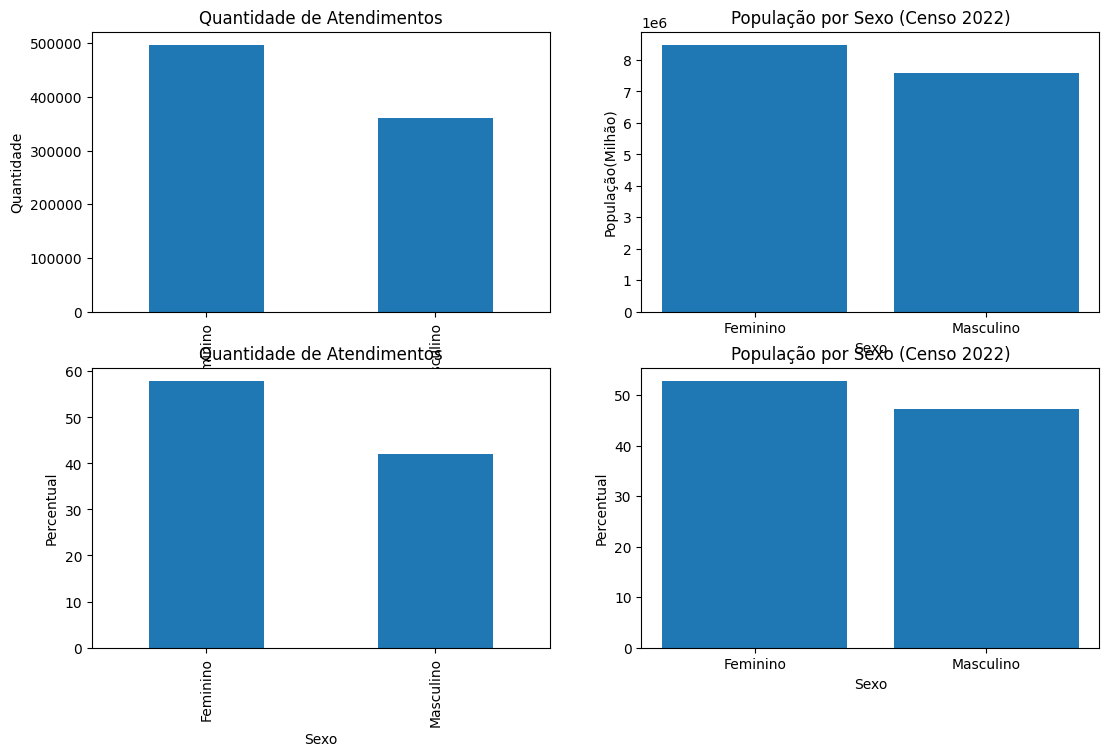

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(13, 8))
histoQtdSexo = axs[0][0]
histoQtdPop = axs[0][1]
histoPercSexo = axs[1][0]
histoPercPop = axs[1][1]

dados["SEXO_LABEL"].value_counts().plot(kind="bar", ax=histoQtdSexo)
histoQtdSexo.set_title("Quantidade de Atendimentos")
histoQtdSexo.set_xlabel("Sexo")
histoQtdSexo.set_ylabel("Quantidade")

dadosPopolucaoQtd = {"Sexo": ["Feminino", "Masculino"], "Populacao": [8477499, 7577675]}
dadosPopolucaoQtd = pd.DataFrame(dadosPopolucaoQtd)
histoQtdPop.bar(dadosPopolucaoQtd["Sexo"], dadosPopolucaoQtd["Populacao"])
histoQtdPop.set_title("População por Sexo (Censo 2022)")
histoQtdPop.set_xlabel("Sexo")
histoQtdPop.set_ylabel("População(Milhão)")

(dados["SEXO_LABEL"].value_counts(normalize=True) * 100).plot(kind="bar", ax=histoPercSexo)
histoPercSexo.set_title("Quantidade de Atendimentos")
histoPercSexo.set_xlabel("Sexo")
histoPercSexo.set_ylabel("Percentual")

dadosPopolucaoPerc = {"Sexo": ["Feminino", "Masculino"], "Populacao": [52.8, 47.2]}
dadosPopolucaoPerc = pd.DataFrame(dadosPopolucaoPerc)
histoPercPop.bar(dadosPopolucaoPerc["Sexo"], dadosPopolucaoPerc["Populacao"])
histoPercPop.set_title("População por Sexo (Censo 2022)")
histoPercPop.set_xlabel("Sexo")
histoPercPop.set_ylabel("Percentual")

plt.show()


**Observação da comparação:** podemos perceber pelos gráficos que o perfil populacional dos atendimentos é compatível ao perfil populacional apresentado pelo IBGE, com uma variação positiva para o público feminino.


#### Item 4 - Avaliação e tratamento das colunas do tipo string

Algoritmos de ML trabalham apenas com números, por isso a importância de avaliar as colunas textuais e gerar representações numéricas quando fizer sentido.

**Neste passo vamos:**

- **4.1 - Verificar os tipos de dados e identificar colunas especiais**
- **4.2 - Avaliar a descrição geral das colunas após identificar os tipos**
- **4.3 - Remover colunas textuais sem confiabilidade suficiente para o recorte**


##### 4.1 - Verificação dos tipos de dados e identificação de colunas especiais


In [15]:
for coluna in dados.columns:
    print(f"{coluna} - {dados[coluna].dtype}")


MES_CMPT - str
IDENT - str
MUNIC_RES - str
NASC - str
SEXO - str
COD_IDADE - str
IDADE - int64
NUM_FILHOS - int64
INSTRU - str
GESTRISCO - str
CONTRACEP1 - str
CONTRACEP2 - str
RACA_COR - str
ETNIA - str
MUNIC_MOV - str
DT_INTER - str
DT_SAIDA - str
DIAS_PERM - int64
QT_DIARIAS - int64
UTI_MES_IN - int64
UTI_MES_AN - int64
UTI_MES_AL - int64
UTI_MES_TO - int64
UTI_INT_IN - int64
UTI_INT_AN - int64
UTI_INT_AL - int64
UTI_INT_TO - int64
MORTE - int64
PROC_REA - str
DIAG_PRINC - str
DIAG_SECUN - str
CID_NOTIF - str
CID_ASSO - str
CID_MORTE - str
DIAGSEC1 - str
DIAGSEC2 - str
DIAGSEC3 - str
DIAGSEC4 - str
DIAGSEC5 - str
DIAGSEC6 - str
DIAGSEC7 - str
DIAGSEC8 - str
DIAGSEC9 - str
TPDISEC1 - str
TPDISEC2 - str
TPDISEC3 - str
TPDISEC4 - str
TPDISEC5 - str
TPDISEC6 - str
TPDISEC7 - str
TPDISEC8 - str
TPDISEC9 - str
COMPLEX - str
VAL_TOT - float64
DIAR_ACOM - int64
SEXO_LABEL - str
NASC_DT - datetime64[us]
ANO_NASC - int32
IDADE_ANOS - int64


##### 4.2 - Avaliação descritiva das colunas após identificação dos tipos

Avaliamos a descrição geral da base para apoiar a decisão sobre colunas especiais, colunas textuais e próximos tratamentos.


In [16]:
dados.describe(include="all")


,MES_CMPT,IDENT,MUNIC_RES,NASC,SEXO,COD_IDADE,IDADE,NUM_FILHOS,INSTRU,GESTRISCO,CONTRACEP1,CONTRACEP2,RACA_COR,ETNIA,MUNIC_MOV,DT_INTER,DT_SAIDA,DIAS_PERM,QT_DIARIAS,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,MORTE,PROC_REA,DIAG_PRINC,DIAG_SECUN,CID_NOTIF,CID_ASSO,CID_MORTE,DIAGSEC1,DIAGSEC2,DIAGSEC3,DIAGSEC4,DIAGSEC5,DIAGSEC6,DIAGSEC7,DIAGSEC8,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,COMPLEX,VAL_TOT,DIAR_ACOM,SEXO_LABEL,NASC_DT,ANO_NASC,IDADE_ANOS
count,857726,857726,857726,857726,857726,857726,857726.000000,857726.000000,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726.000000,857726.000000,857726.0,857726.0,857726.0,857726.000000,857726.0,857726.0,857726.0,857726.00000,857726.000000,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726.000000,857726.000000,857726,857726,857726.000000,857726.000000
unique,12,2,791,36269,2,4,NaN,NaN,5,2,14,14,5,14,83,365,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1525,7130,1,20,1,1,4959,2662,1751,1168,732,460,248,87,14,3,3,3,3,3,3,3,3,3,2,NaN,NaN,2,NaN,NaN,NaN
top,10,1,330455,20250313,3,4,NaN,NaN,0,1,00,00,03,0000,330455,20250701,20250930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0310010039,O800,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,NaN,NaN,Feminino,NaN,NaN,NaN
freq,80617,854622,265691,184,496631,815189,NaN,NaN,821522,852674,821522,829666,494812,857675,325660,4098,4134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47946,40162,857726,821522,857726,857726,672613,827614,843381,851134,854919,856511,857265,857601,857687,672613,827614,843381,851134,854919,856511,857265,857601,857687,781185,NaN,NaN,496631,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,44.394449,0.098353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.520743,4.931787,0.0,0.0,0.0,0.692602,0.0,0.0,0.0,0.04738,0.062463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1791.032551,2.165770,NaN,1980-09-17 19:18:34.484579,1980.226479,44.260743
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,1897-01-22 00:00:00,1897.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,388.140000,0.000000,NaN,1959-07-29 00:00:00,1959.000000,25.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,44.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,3.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,697.110000,0.000000,NaN,1980-08-22 00:00:00,1980.000000,44.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,65.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,6.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1315.452500,2.000000,NaN,2000-01-13 00:00:00,2000.000000,65.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,99.000000,69.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,345.000000,345.000000,0.0,0.0,0.0,184.000000,0.0,0.0,0.0,96.00000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163570.270000,204.000000,NaN,2025-12-31 00:00:00,2025.000000,100.000000


##### 4.3 - Remoção da coluna ETNIA

**Vamos remover a coluna ETNIA, pois seus dados não apresentam confiabilidade suficiente para este recorte.**


In [17]:
dados = dados.drop(columns=["ETNIA"])


#### Item 5 - Tratamento dos campos CID

**Tratamento dos campos CID**

Neste passo vamos:

- **5.1 - Avaliar CIDs inválidos em todos os campos CID mantidos no recorte**
- **5.2 - Gerar representações numéricas para todos os campos CID**
- **5.3 - Categorizar o CID do diagnóstico principal por capítulo/tema clínico**
- Usar todos os campos CID para identificar indícios de violência contra mulher e câncer de mama em etapas posteriores.

Padrão CID usado na validação:

- 1 letra
- 2 números
- opcionalmente 1 ou 2 caracteres alfanuméricos


##### 5.1 - Validação do formato dos campos CID mantidos no recorte

Nesta etapa vamos verificar quais campos CID respeitam o padrão esperado e criar colunas auxiliares de validação para apoiar os tratamentos seguintes.


In [18]:
colunas_cid = [
    "DIAG_PRINC",
    "DIAG_SECUN",
    "CID_ASSO",
    "CID_NOTIF",
    "DIAGSEC1",
    "DIAGSEC2",
    "DIAGSEC3",
    "DIAGSEC4",
    "DIAGSEC5",
    "DIAGSEC6",
    "DIAGSEC7",
    "DIAGSEC8",
    "DIAGSEC9",
    "CID_MORTE"
]

def campo_respeita_formato_cid(valor: str) -> bool:
    if valor is None:
        return False

    valor_tratado = str(valor).strip().upper()
    if valor_tratado == "" or valor_tratado in ["NAN", "NONE"]:
        return False

    padrao_cid = r'^[A-Z][0-9]{2}([A-Z0-9]{1,2})?$'
    return re.fullmatch(padrao_cid, valor_tratado) is not None


for coluna_cid in colunas_cid:
    dados[f"{coluna_cid}_VALIDA"] = dados[coluna_cid].apply(campo_respeita_formato_cid)


In [19]:
dados.shape


(857726, 72)

In [20]:
validade_cid = []
for coluna_cid in colunas_cid:
    total_registros = dados.shape[0]
    total_validos = dados[f"{coluna_cid}_VALIDA"].sum()
    total_invalidos = total_registros - total_validos
    validade_cid.append({
        "COLUNA_CID": coluna_cid,
        "VALIDOS": int(total_validos),
        "INVALIDOS_OU_VAZIOS": int(total_invalidos),
        "PERCENTUAL_VALIDO": round((total_validos / total_registros) * 100, 2),
    })

pd.DataFrame(validade_cid)


,COLUNA_CID,VALIDOS,INVALIDOS_OU_VAZIOS,PERCENTUAL_VALIDO
0,DIAG_PRINC,857726,0,100.00
1,DIAG_SECUN,0,857726,0.00
2,CID_ASSO,0,857726,0.00
3,CID_NOTIF,36204,821522,4.22
4,DIAGSEC1,185113,672613,21.58
5,DIAGSEC2,30112,827614,3.51
6,DIAGSEC3,14345,843381,1.67
7,DIAGSEC4,6592,851134,0.77
8,DIAGSEC5,2807,854919,0.33
9,DIAGSEC6,1215,856511,0.14


##### 5.2 - Geração de CIDs numéricos para todos os campos CID mantidos


In [21]:
def cid_para_numero(cid, maxLength: int) -> int:
    try:
        cid = str(cid).strip().upper()

        if cid == "" or cid in ["NAN", "NONE"]:
            return 0

        letra = cid[0]

        if(not letra.isalpha()):
           return 0
        
        numero = cid[1:].replace(".", "").ljust(maxLength - 1, "0")

        valor_letra = ord(letra) - ord('A') + 1

        return int(f"{valor_letra}{numero}")    
    except:
        return 0

for coluna_cid in colunas_cid:
    dados[f"{coluna_cid}_INT"] = dados[coluna_cid].apply(lambda cid: cid_para_numero(cid, 3))


In [22]:
cid_int_zerado = []
for coluna_cid in colunas_cid:
    cid_int_zerado.append({
        "COLUNA_CID": coluna_cid,
        "QTD_ZERO": int((dados[f"{coluna_cid}_INT"] == 0).sum()),
    })

pd.DataFrame(cid_int_zerado)


,COLUNA_CID,QTD_ZERO
0,DIAG_PRINC,0
1,DIAG_SECUN,857726
2,CID_ASSO,857726
3,CID_NOTIF,821522
4,DIAGSEC1,672613
5,DIAGSEC2,827614
6,DIAGSEC3,843381
7,DIAGSEC4,851134
8,DIAGSEC5,854919
9,DIAGSEC6,856511


##### 5.3 - Categorização do CID do diagnóstico principal

Agora vamos agrupar o CID do diagnóstico principal por capítulo/tema clínico. Esse agrupamento reduz a cardinalidade do campo `DIAG_PRINC` e cria uma representação mais adequada para análises exploratórias e modelos de machine learning.

As categorias criadas para `DIAG_PRINC_GRUPO` serão:

- **0 - Vazio, inválido ou não classificado**
- **1 - A-B:** doenças infecciosas e parasitárias
- **2 - C-D:** neoplasias e doenças do sangue/sistema imune
- **3 - E:** doenças endócrinas, nutricionais e metabólicas
- **4 - F:** transtornos mentais e comportamentais
- **5 - G:** doenças do sistema nervoso
- **6 - H:** doenças dos olhos, anexos, ouvido e apófise mastoide
- **7 - I:** doenças do aparelho circulatório
- **8 - J:** doenças do aparelho respiratório
- **9 - K:** doenças do aparelho digestivo
- **10 - M:** doenças do sistema osteomuscular e tecido conjuntivo
- **11 - N:** doenças do aparelho geniturinário
- **12 - O-P:** gravidez, parto, puerpério e condições originadas no período perinatal
- **13 - Q:** malformações congênitas e anomalias cromossômicas
- **14 - R:** sintomas, sinais e achados anormais não classificados em outra parte
- **15 - S, T, V, W, X, Y:** lesões, envenenamentos e causas externas
- **16 - Z:** fatores que influenciam o estado de saúde e contato com serviços de saúde


In [23]:
def agrupar_cid_numerico(cid: str) -> int:
    if not isinstance(cid, str) or len(cid.strip()) == 0:
        return 0
    letra = cid.strip()[0].upper()
    if letra in ["A", "B"]:
        return 1
    elif letra in ["C", "D"]:
        return 2
    elif letra == "E":
        return 3
    elif letra == "F":
        return 4
    elif letra == "G":
        return 5
    elif letra == "H":
        return 6
    elif letra == "I":
        return 7
    elif letra == "J":
        return 8
    elif letra == "K":
        return 9
    elif letra == "M":
        return 10
    elif letra == "N":
        return 11
    elif letra in ["O", "P"]:
        return 12
    elif letra == "Q":
        return 13
    elif letra == "R":
        return 14
    elif letra in ["S", "T", "V", "W", "X", "Y"]:
        return 15
    elif letra == "Z":
        return 16
    return 0


dados["DIAG_PRINC_GRUPO"] = dados["DIAG_PRINC"].apply(agrupar_cid_numerico)


#### Item 6 - Identificação de indícios de câncer de mama em todos os campos CID

**Neste passo consolidamos os indícios encontrados nos campos CID para sustentar a geração do target binário final de classificação.**

**Para a apresentação, a leitura deve ser feita assim:**

- **0 - Sem indício**
- **1 - Com indício**


In [24]:
def classificar_cancer_mama(cid: object) -> int:
    cid = str(cid)
    if len(cid.strip()) == 0:
        return 0
    cid = cid.strip().upper()
    if cid.startswith("C50"):
        return 3
    if cid.startswith("D05") or cid.startswith("Z85.3") or cid.startswith("Z853"):
        return 2
    if cid.startswith("N63") or cid.startswith("N64"):
        return 1
    return 0

colunas_cancer_mama_cid = []
for coluna_cid in colunas_cid:
    coluna_temp = f"cancer_mama_{coluna_cid}"
    dados[coluna_temp] = dados[coluna_cid].apply(classificar_cancer_mama)
    colunas_cancer_mama_cid.append(coluna_temp)

dados["CANCER_MAMA_NIVEL"] = dados[colunas_cancer_mama_cid].max(axis=1)
dados = dados.drop(columns=colunas_cancer_mama_cid)


In [25]:
dados.groupby("CANCER_MAMA_NIVEL").size()


CANCER_MAMA_NIVEL
0    848560
1       920
2       174
3      8072
dtype: int64

> Nota para apresentação: esta versão consolidada foi enxugada para manter o foco no target binário de indício de câncer de mama.

#### Item 7 - Tratamento da coluna do mês

**Neste passo vamos:**

- **7.1 - Avaliar as competências registradas e manter apenas as referentes ao ano de 2025**
- **7.2 - Validar a coluna `MES_CMPT` no formato MM**


In [28]:
dados.groupby("MES_CMPT").size()


MES_CMPT
01    36112
02    55419
03    66198
04    72152
05    78162
06    77672
07    80373
08    78804
09    80056
10    80617
11    76777
12    75384
dtype: int64

#### Item 8 - Geração da base tratada final

**Neste passo vamos:**

- **8.1 - Remover colunas temporárias e que não serão utilizadas**
- **8.2 - Gerar arquivo Parquet final tratado**
- **8.3 - Validar tipos finais, colunas finais e estrutura da base tratada**

A base tratada lógica contém **857.726 registros** e **74 colunas de dados** após o recorte de internações com `DT_INTER` em 2025, remoção de `ETNIA`, criação de variáveis derivadas e remoção das flags auxiliares que não serão usadas. No arquivo Parquet salvo pode aparecer a coluna técnica `__index_level_0__`, criada pela gravação do índice do DataFrame; ela não representa uma variável analítica.



In [29]:
print("\n".join(dados.columns))


MES_CMPT
IDENT
MUNIC_RES
NASC
SEXO
COD_IDADE
IDADE
NUM_FILHOS
INSTRU
GESTRISCO
CONTRACEP1
CONTRACEP2
RACA_COR
MUNIC_MOV
DT_INTER
DT_SAIDA
DIAS_PERM
QT_DIARIAS
UTI_MES_IN
UTI_MES_AN
UTI_MES_AL
UTI_MES_TO
UTI_INT_IN
UTI_INT_AN
UTI_INT_AL
UTI_INT_TO
MORTE
PROC_REA
DIAG_PRINC
DIAG_SECUN
CID_NOTIF
CID_ASSO
CID_MORTE
DIAGSEC1
DIAGSEC2
DIAGSEC3
DIAGSEC4
DIAGSEC5
DIAGSEC6
DIAGSEC7
DIAGSEC8
DIAGSEC9
TPDISEC1
TPDISEC2
TPDISEC3
TPDISEC4
TPDISEC5
TPDISEC6
TPDISEC7
TPDISEC8
TPDISEC9
COMPLEX
VAL_TOT
DIAR_ACOM
SEXO_LABEL
NASC_DT
ANO_NASC
IDADE_ANOS
DIAG_PRINC_VALIDA
DIAG_SECUN_VALIDA
CID_ASSO_VALIDA
CID_NOTIF_VALIDA
DIAGSEC1_VALIDA
DIAGSEC2_VALIDA
DIAGSEC3_VALIDA
DIAGSEC4_VALIDA
DIAGSEC5_VALIDA
DIAGSEC6_VALIDA
DIAGSEC7_VALIDA
DIAGSEC8_VALIDA
DIAGSEC9_VALIDA
CID_MORTE_VALIDA
DIAG_PRINC_INT
DIAG_SECUN_INT
CID_ASSO_INT
CID_NOTIF_INT
DIAGSEC1_INT
DIAGSEC2_INT
DIAGSEC3_INT
DIAGSEC4_INT
DIAGSEC5_INT
DIAGSEC6_INT
DIAGSEC7_INT
DIAGSEC8_INT
DIAGSEC9_INT
CID_MORTE_INT
DIAG_PRINC_GRUPO
CANCER_MAMA_NIVEL
VIOLENC

In [30]:
colunasParaRemover = colunas_validacao = [
    "DIAG_PRINC_VALIDA",
    "CID_ASSO_VALIDA",
    "CID_NOTIF_VALIDA",
    "DIAGSEC1_VALIDA",
    "DIAGSEC2_VALIDA",
    "DIAGSEC3_VALIDA",
    "DIAGSEC4_VALIDA",
    "DIAGSEC5_VALIDA",
    "DIAGSEC6_VALIDA",
    "DIAGSEC7_VALIDA",
    "DIAGSEC8_VALIDA",
    "DIAGSEC9_VALIDA",
    "CID_MORTE_VALIDA",
    "SEXO_LABEL"
]
dados = dados.drop(columns=colunasParaRemover)

for coluna in dados.columns:
    print(f"{coluna} - {dados[coluna].dtype}")



MES_CMPT - str
IDENT - str
MUNIC_RES - str
NASC - str
SEXO - str
COD_IDADE - str
IDADE - int64
NUM_FILHOS - int64
INSTRU - str
GESTRISCO - str
CONTRACEP1 - str
CONTRACEP2 - str
RACA_COR - str
MUNIC_MOV - str
DT_INTER - str
DT_SAIDA - str
DIAS_PERM - int64
QT_DIARIAS - int64
UTI_MES_IN - int64
UTI_MES_AN - int64
UTI_MES_AL - int64
UTI_MES_TO - int64
UTI_INT_IN - int64
UTI_INT_AN - int64
UTI_INT_AL - int64
UTI_INT_TO - int64
MORTE - int64
PROC_REA - str
DIAG_PRINC - str
DIAG_SECUN - str
CID_NOTIF - str
CID_ASSO - str
CID_MORTE - str
DIAGSEC1 - str
DIAGSEC2 - str
DIAGSEC3 - str
DIAGSEC4 - str
DIAGSEC5 - str
DIAGSEC6 - str
DIAGSEC7 - str
DIAGSEC8 - str
DIAGSEC9 - str
TPDISEC1 - str
TPDISEC2 - str
TPDISEC3 - str
TPDISEC4 - str
TPDISEC5 - str
TPDISEC6 - str
TPDISEC7 - str
TPDISEC8 - str
TPDISEC9 - str
COMPLEX - str
VAL_TOT - float64
DIAR_ACOM - int64
NASC_DT - datetime64[us]
ANO_NASC - int32
IDADE_ANOS - int64
DIAG_SECUN_VALIDA - bool
DIAG_PRINC_INT - int64
DIAG_SECUN_INT - int64
CID_ASSO_IN

In [31]:
dados.to_parquet("2025_tratado.parquet", engine="pyarrow")
dados.info()


<class 'pandas.DataFrame'>
Index: 857726 entries, 9 to 925239
Data columns (total 75 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   MES_CMPT                857726 non-null  str           
 1   IDENT                   857726 non-null  str           
 2   MUNIC_RES               857726 non-null  str           
 3   NASC                    857726 non-null  str           
 4   SEXO                    857726 non-null  str           
 5   COD_IDADE               857726 non-null  str           
 6   IDADE                   857726 non-null  int64         
 7   NUM_FILHOS              857726 non-null  int64         
 8   INSTRU                  857726 non-null  str           
 9   GESTRISCO               857726 non-null  str           
 10  CONTRACEP1              857726 non-null  str           
 11  CONTRACEP2              857726 non-null  str           
 12  RACA_COR                857726 non-null  str  

##### Dicionário de Dados - base tratada final

| Ordem | Coluna | Tipo | Descrição |
|---:|---|---|---|
| 1 | MES_CMPT | str | Mês de competência/processamento da informação. |
| 2 | IDENT | str | Identificação do tipo de AIH. |
| 3 | MUNIC_RES | str | Código IBGE do município de residência do paciente. |
| 4 | NASC | str | Data de nascimento original no formato aaaammdd. |
| 5 | SEXO | str | Sexo do paciente no código original. |
| 6 | COD_IDADE | str | Unidade de medida da idade original. |
| 7 | IDADE | int64 | Idade original conforme COD_IDADE. |
| 8 | NUM_FILHOS | int64 | Quantidade de filhos informada. |
| 9 | INSTRU | str | Grau de instrução. |
| 10 | GESTRISCO | str | Indicador de gestante de alto risco. |
| 11 | CONTRACEP1 | str | Método contraceptivo 1. |
| 12 | CONTRACEP2 | str | Método contraceptivo 2. |
| 13 | RACA_COR | str | Raça/cor do paciente. |
| 14 | DT_INTER | str | Data da internação. |
| 15 | DT_SAIDA | str | Data de saída/alta. |
| 16 | DIAS_PERM | int64 | Quantidade de dias de permanência. |
| 17 | QT_DIARIAS | int64 | Quantidade de diárias da internação. |
| 18 | UTI_MES_IN | int64 | Dias de UTI no mês inicial. |
| 19 | UTI_MES_AN | int64 | Dias de UTI em mês anterior ao mês da alta. |
| 20 | UTI_MES_AL | int64 | Dias de UTI no mês da alta. |
| 21 | UTI_MES_TO | int64 | Total de dias/atos de UTI. |
| 22 | UTI_INT_IN | int64 | Dias em unidade intermediária no mês inicial. |
| 23 | UTI_INT_AN | int64 | Dias em unidade intermediária em mês anterior ao mês da alta. |
| 24 | UTI_INT_AL | int64 | Dias em unidade intermediária no mês da alta. |
| 25 | UTI_INT_TO | int64 | Total de dias em unidade intermediária. |
| 26 | MORTE | int64 | Indicador de óbito. |
| 27 | PROC_REA | str | Código do procedimento realizado. |
| 28 | DIAG_PRINC | str | CID do diagnóstico principal. |
| 29 | DIAG_SECUN | str | CID do diagnóstico secundário. |
| 30 | CID_NOTIF | str | CID de notificação. |
| 31 | CID_ASSO | str | CID associado/causa. |
| 32 | CID_MORTE | str | CID associado ao óbito. |
| 33 | DIAGSEC1 | str | CID secundário 1. |
| 34 | DIAGSEC2 | str | CID secundário 2. |
| 35 | DIAGSEC3 | str | CID secundário 3. |
| 36 | DIAGSEC4 | str | CID secundário 4. |
| 37 | DIAGSEC5 | str | CID secundário 5. |
| 38 | DIAGSEC6 | str | CID secundário 6. |
| 39 | DIAGSEC7 | str | CID secundário 7. |
| 40 | DIAGSEC8 | str | CID secundário 8. |
| 41 | DIAGSEC9 | str | CID secundário 9. |
| 42 | TPDISEC1 | str | Tipo/classificação do diagnóstico secundário 1. |
| 43 | TPDISEC2 | str | Tipo/classificação do diagnóstico secundário 2. |
| 44 | TPDISEC3 | str | Tipo/classificação do diagnóstico secundário 3. |
| 45 | TPDISEC4 | str | Tipo/classificação do diagnóstico secundário 4. |
| 46 | TPDISEC5 | str | Tipo/classificação do diagnóstico secundário 5. |
| 47 | TPDISEC6 | str | Tipo/classificação do diagnóstico secundário 6. |
| 48 | TPDISEC7 | str | Tipo/classificação do diagnóstico secundário 7. |
| 49 | TPDISEC8 | str | Tipo/classificação do diagnóstico secundário 8. |
| 50 | TPDISEC9 | str | Tipo/classificação do diagnóstico secundário 9. |
| 51 | COMPLEX | str | Complexidade do procedimento/atendimento. |
| 52 | VAL_TOT | float64 | Valor total aprovado/pago da AIH. |
| 53 | DIAR_ACOM | int64 | Quantidade de diárias de acompanhante. |
| 54 | NASC_DT | datetime64[us] | Data de nascimento convertida para formato datetime. |
| 55 | ANO_NASC | int32 | Ano de nascimento derivado de NASC_DT. |
| 56 | IDADE_ANOS | int64 | Idade padronizada em anos. |
| 57 | DIAG_SECUN_VALIDA | bool | Flag de validação do formato CID para DIAG_SECUN. |
| 58 | DIAG_PRINC_INT | int64 | Representação numérica derivada de DIAG_PRINC. |
| 59 | DIAG_SECUN_INT | int64 | Representação numérica derivada de DIAG_SECUN. |
| 60 | CID_ASSO_INT | int64 | Representação numérica derivada de CID_ASSO. |
| 61 | CID_NOTIF_INT | int64 | Representação numérica derivada de CID_NOTIF. |
| 62 | DIAGSEC1_INT | int64 | Representação numérica derivada de DIAGSEC1. |
| 63 | DIAGSEC2_INT | int64 | Representação numérica derivada de DIAGSEC2. |
| 64 | DIAGSEC3_INT | int64 | Representação numérica derivada de DIAGSEC3. |
| 65 | DIAGSEC4_INT | int64 | Representação numérica derivada de DIAGSEC4. |
| 66 | DIAGSEC5_INT | int64 | Representação numérica derivada de DIAGSEC5. |
| 67 | DIAGSEC6_INT | int64 | Representação numérica derivada de DIAGSEC6. |
| 68 | DIAGSEC7_INT | int64 | Representação numérica derivada de DIAGSEC7. |
| 69 | DIAGSEC8_INT | int64 | Representação numérica derivada de DIAGSEC8. |
| 70 | DIAGSEC9_INT | int64 | Representação numérica derivada de DIAGSEC9. |
| 71 | CID_MORTE_INT | int64 | Representação numérica derivada de CID_MORTE. |
| 72 | DIAG_PRINC_GRUPO | int64 | Agrupamento do diagnóstico principal por capítulo/letra CID. |
| 73 | CANCER_MAMA_NIVEL | int64 | Variável auxiliar construída a partir dos CIDs para apoiar a geração do target binário final de indício de câncer de mama. |

---

# Seção: `trabalho_parte_3.ipynb`

Origem: `ia_tech_challenge_01/trabalho_parte_3.ipynb`

### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs

#### Parte 3 - Classificação supervisionada com SVM e Random Forest

- `SVM` com padronização (`StandardScaler`)
- `RandomForestClassifier`
- `Tuning Leve`

## Sumário da Parte 3

### Item 1 - Carregamento da base e definição do target
### Item 2 - Seleção de features e prevenção de vazamento
### Item 3 - Separação treino/teste
### Item 4 - Pré-processamento com `ColumnTransformer`
### Item 5 - Tuning leve do SVM
### Item 6 - Tuning leve do Random Forest
### Item 7 - Avaliação final no conjunto de teste
### Item 8 - Comparação dos modelos

#### Item 1 - Carregamento da base e definição do target

Nesta etapa carregamos a base tratada e criamos a variável binária `TARGET`:
- `0` para casos sem indício
- `1` para casos com indício (`CANCER_MAMA_NIVEL > 0`)

Também verificamos dimensões da base e distribuição das classes.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

candidate_paths = [
    Path('2025_tratado.parquet'),
    Path('ia_tech_challenge_01/2025_tratado.parquet'),
    Path('/content/2025_tratado.parquet'),
    Path('/content/drive/MyDrive/2025_tratado.parquet'),
    Path('/content/drive/MyDrive/ia_tech_challenge_01/2025_tratado.parquet'),
]

path = next((candidate for candidate in candidate_paths if candidate.exists()), None)
if path is None:
    searched = '\n'.join(f'- {candidate}' for candidate in candidate_paths)
    raise FileNotFoundError(
        'Arquivo de base tratada não encontrado. Verifique onde o arquivo '
        "'2025_tratado.parquet' foi salvo e ajuste o caminho na célula.\n"
        f'Caminhos verificados:\n{searched}'
    )

print(f'Arquivo localizado em: {path.resolve()}')
dados = pd.read_parquet(path)

TARGET = 'TARGET'
dados[TARGET] = (dados['CANCER_MAMA_NIVEL'] > 0).astype(int)

print('Dimensões da base tratada:', dados.shape)
print('\nDistribuição do target:')
print(dados[TARGET].value_counts().sort_index())
print('\nProporção do target:')
print(dados[TARGET].value_counts(normalize=True).sort_index().rename('proporcao'))

Arquivo localizado em: C:\Users\Rodrigo\Desktop\Pós\Tech_Challenge_1\ia_tech_challenge_01\2025_tratado.parquet
Dimensões da base tratada: (857726, 76)

Distribuição do target:
TARGET
0    848560
1      9166
Name: count, dtype: int64

Proporção do target:
TARGET
0    0.989314
1    0.010686
Name: proporcao, dtype: float64


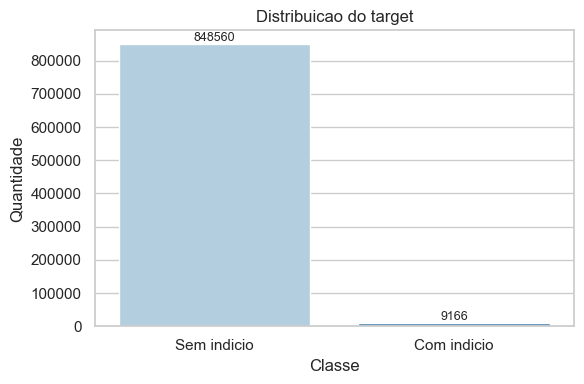

In [4]:
plot_df = dados[TARGET].value_counts().sort_index().rename_axis('Classe').reset_index(name='Quantidade')
plot_df['Classe'] = plot_df['Classe'].map({0: 'Sem indicio', 1: 'Com indicio'})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=plot_df, x='Classe', y='Quantidade', hue='Classe', palette='Blues', legend=False)
ax.set_title('Distribuicao do target')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade')
for patch in ax.patches:
    ax.annotate(
        f"{int(patch.get_height())}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
    )
plt.tight_layout()
plt.show()

#### Item 2 - Seleção de features e prevenção de vazamento

A seleção de atributos prioriza variáveis administrativas e demográficas, evitando colunas diretamente associadas ao diagnóstico detalhado para reduzir risco de vazamento.

In [5]:
feature_candidates = [
    'IDADE_ANOS',
    'DIAS_PERM',
    'QT_DIARIAS',
    'UTI_MES_IN',
    'UTI_MES_AN',
    'UTI_MES_AL',
    'UTI_MES_TO',
    'UTI_INT_IN',
    'UTI_INT_AN',
    'UTI_INT_AL',
    'UTI_INT_TO',
    'DIAR_ACOM',
    'SEXO',
    'RACA_COR',
    'GESTRISCO',
    'CONTRACEP1',
    'CONTRACEP2',
    'PROC_REA',
]

leakage_columns = [
    'CANCER_MAMA_NIVEL',
    'DIAG_PRINC',
    'DIAGSEC1',
    'DIAGSEC2',
    'DIAGSEC3',
    'DIAGSEC4',
    'DIAGSEC5',
    'DIAGSEC6',
    'DIAGSEC7',
    'CID_MORTE',
    'DIAG_PRINC_GRUPO',
]

features = [col for col in feature_candidates if col in dados.columns]
leakage_present = [col for col in leakage_columns if col in dados.columns]

numerical_features = [col for col in features if dados[col].dtype.kind in 'biufc']
categorical_features = [col for col in features if col not in numerical_features]

low_cardinality_features = []
high_cardinality_features = []
for col in categorical_features:
    nunique = dados[col].nunique(dropna=False)
    if nunique <= 20:
        low_cardinality_features.append(col)
    else:
        high_cardinality_features.append(col)

selected_features = numerical_features + low_cardinality_features
X = dados[selected_features].copy()
y = dados[TARGET].copy()

print('Features selecionadas para modelagem:')
print(selected_features)
print('\nColunas sensíveis identificadas e excluídas:')
print(leakage_present)
print('\nCategóricas excluídas por alta cardinalidade:')
print(high_cardinality_features)
print('\nDimensões de X e y:', X.shape, y.shape)

Features selecionadas para modelagem:
['IDADE_ANOS', 'DIAS_PERM', 'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO', 'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'DIAR_ACOM', 'SEXO', 'RACA_COR', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2']

Colunas sensíveis identificadas e excluídas:
['CANCER_MAMA_NIVEL', 'DIAG_PRINC', 'DIAGSEC1', 'DIAGSEC2', 'DIAGSEC3', 'DIAGSEC4', 'DIAGSEC5', 'DIAGSEC6', 'DIAGSEC7', 'CID_MORTE', 'DIAG_PRINC_GRUPO']

Categóricas excluídas por alta cardinalidade:
['PROC_REA']

Dimensões de X e y: (857726, 17) (857726,)


In [6]:
print('\nValores ausentes por coluna:')
print(X.isna().sum().sort_values(ascending=False))


Valores ausentes por coluna:
IDADE_ANOS    0
DIAS_PERM     0
QT_DIARIAS    0
UTI_MES_IN    0
UTI_MES_AN    0
UTI_MES_AL    0
UTI_MES_TO    0
UTI_INT_IN    0
UTI_INT_AN    0
UTI_INT_AL    0
UTI_INT_TO    0
DIAR_ACOM     0
SEXO          0
RACA_COR      0
GESTRISCO     0
CONTRACEP1    0
CONTRACEP2    0
dtype: int64


#### Item 3 - Separação treino/teste

Utilizamos `train_test_split` com estratificação (`stratify=y`) para manter a mesma proporção de classes nos dois conjuntos.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Treino:', X_train.shape, 'Teste:', X_test.shape)
print('\nProporção de classes no treino:')
print(y_train.value_counts(normalize=True).sort_index())
print('\nProporção de classes no teste:')
print(y_test.value_counts(normalize=True).sort_index())

Treino: (686180, 17) Teste: (171546, 17)

Proporção de classes no treino:
TARGET
0    0.989313
1    0.010687
Name: proportion, dtype: float64

Proporção de classes no teste:
TARGET
0    0.989315
1    0.010685
Name: proportion, dtype: float64


#### Item 4 - Pré-processamento com `ColumnTransformer`

Como o SVM é sensível à escala dos dados, aplicamos `StandardScaler` nas variáveis numéricas.

Esse fluxo é organizado em um `Pipeline`, evitando vazamento entre treino e teste.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, low_cardinality_features),
])

print('Pré-processador montado com sucesso.')
print('Numéricas:', numerical_features)
print('Categóricas one-hot:', low_cardinality_features)

Pré-processador montado com sucesso.
Numéricas: ['IDADE_ANOS', 'DIAS_PERM', 'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO', 'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'DIAR_ACOM']
Categóricas one-hot: ['SEXO', 'RACA_COR', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2']


#### Item 5 - Tuning leve do SVM

Aqui aplicamos uma busca curta de hiperparâmetros com validação cruzada estratificada.

Como a base pode ser grande, usamos uma amostra estratificada do treino para tornar o ajuste viável sem perder representatividade.

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC

svm_train_size = min(50000, len(X_train))
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train,
    y_train,
    train_size=svm_train_size,
    random_state=42,
    stratify=y_train,
)

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(class_weight='balanced', random_state=42, max_iter=10000)),
])

svm_param_grid = {
    'classifier__C': [0.5, 1.0, 2.0],
    'classifier__loss': ['squared_hinge'],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

svm_search.fit(X_train_svm, y_train_svm)

print('Melhores parâmetros SVM:', svm_search.best_params_)
print(f"Melhor recall médio (CV): {svm_search.best_score_:.4f}")

svm_tuning_df = pd.DataFrame(svm_search.cv_results_)[[
    'params',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]].sort_values(by='rank_test_score').reset_index(drop=True)
svm_tuning_df.head(10)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Melhores parâmetros SVM: {'classifier__C': 0.5, 'classifier__loss': 'squared_hinge'}
Melhor recall médio (CV): 0.9270


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__C': 0.5, 'classifier__loss': 'sq...",0.926966,0.02554,1
1,"{'classifier__C': 1.0, 'classifier__loss': 'sq...",0.926966,0.02554,1
2,"{'classifier__C': 2.0, 'classifier__loss': 'sq...",0.926966,0.02554,1


#### Item 6 - Tuning leve do Random Forest

Para o Random Forest, fazemos outra busca curta, variando profundidade e tamanho da floresta.
A métrica-alvo também é `recall`, priorizando menor risco de deixar casos positivos passarem despercebidos.

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=1,
    )),
])

rf_param_grid = {
    'classifier__n_estimators': [100, 150], 
    'classifier__max_depth': [8, 12],        
    'classifier__min_samples_leaf': [5, 10],
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

rf_train_size = min(30000, len(X_train))

X_train_rf, _, y_train_rf, _ = train_test_split(
    X_train,
    y_train,
    train_size=rf_train_size,
    random_state=42,
    stratify=y_train,
)

rf_search.fit(X_train_rf, y_train_rf)

print('Melhores parâmetros Random Forest:', rf_search.best_params_)
print(f"Melhor recall médio (CV): {rf_search.best_score_:.4f}")

rf_tuning_df = pd.DataFrame(rf_search.cv_results_)[[
    'params',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]].sort_values(by='rank_test_score').reset_index(drop=True)
rf_tuning_df.head(10)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores parâmetros Random Forest: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 150}
Melhor recall médio (CV): 0.8567


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__max_depth': 8, 'classifier__min_...",0.856698,0.039158,1
1,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
2,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
3,"{'classifier__max_depth': 8, 'classifier__min_...",0.847352,0.039158,4
4,"{'classifier__max_depth': 12, 'classifier__min...",0.778816,0.069240,5
5,"{'classifier__max_depth': 12, 'classifier__min...",0.772586,0.073325,6
6,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7
7,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7


#### Item 7 - Avaliação final no conjunto de teste

Com os melhores hiperparâmetros encontrados, treinamos os modelos finais e avaliamos em `X_test`.

As métricas analisadas são:
- `accuracy`
- `precision`
- `recall`
- `f1-score`
- matriz de confusão

In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

best_svm = svm_search.best_estimator_
best_rf = rf_search.best_estimator_

best_svm.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

modelos_finais = {
    'SVM (com scaler)': best_svm,
    'Random Forest': best_rf,
}

resultados = []
matrizes = {}

for nome, modelo in modelos_finais.items():
    y_pred = modelo.predict(X_test)

    matriz = confusion_matrix(y_test, y_pred)
    matrizes[nome] = matriz

    resultados.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
    })

    print(f'--- {nome} ---')
    print(classification_report(y_test, y_pred, zero_division=0))
    print('Matriz de confusão:')
    print(pd.DataFrame(matriz, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))
    print()

resultados_df = (
    pd.DataFrame(resultados)
    .set_index('Modelo')
    .sort_values(by=['Recall', 'F1', 'Precision'], ascending=False)
    .round(4)
)

resultados_df

--- SVM (com scaler) ---
              precision    recall  f1-score   support

           0       1.00      0.69      0.82    169713
           1       0.03      0.93      0.06      1833

    accuracy                           0.70    171546
   macro avg       0.52      0.81      0.44    171546
weighted avg       0.99      0.70      0.81    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  117731   51982
Real 1     133    1700

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      0.72      0.84    169713
           1       0.03      0.92      0.07      1833

    accuracy                           0.73    171546
   macro avg       0.52      0.82      0.45    171546
weighted avg       0.99      0.73      0.83    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  122688   47025
Real 1     144    1689



,Accuracy,Precision,Recall,F1
Modelo,,,,
SVM (com scaler),0.6962,0.0317,0.9274,0.0612
Random Forest,0.7250,0.0347,0.9214,0.0668


#### Item 8 - Comparação dos modelos

A tabela final facilita a decisão entre os modelos com base no objetivo do projeto.
No contexto de triagem em saúde, o principal critério é o `recall`, sem ignorar o trade-off com `precision`.

,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__C': 0.5, 'classifier__loss': 'sq...",0.926966,0.02554,1
1,"{'classifier__C': 1.0, 'classifier__loss': 'sq...",0.926966,0.02554,1
2,"{'classifier__C': 2.0, 'classifier__loss': 'sq...",0.926966,0.02554,1


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__max_depth': 8, 'classifier__min_...",0.856698,0.039158,1
1,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
2,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
3,"{'classifier__max_depth': 8, 'classifier__min_...",0.847352,0.039158,4
4,"{'classifier__max_depth': 12, 'classifier__min...",0.778816,0.069240,5
5,"{'classifier__max_depth': 12, 'classifier__min...",0.772586,0.073325,6
6,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7
7,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7


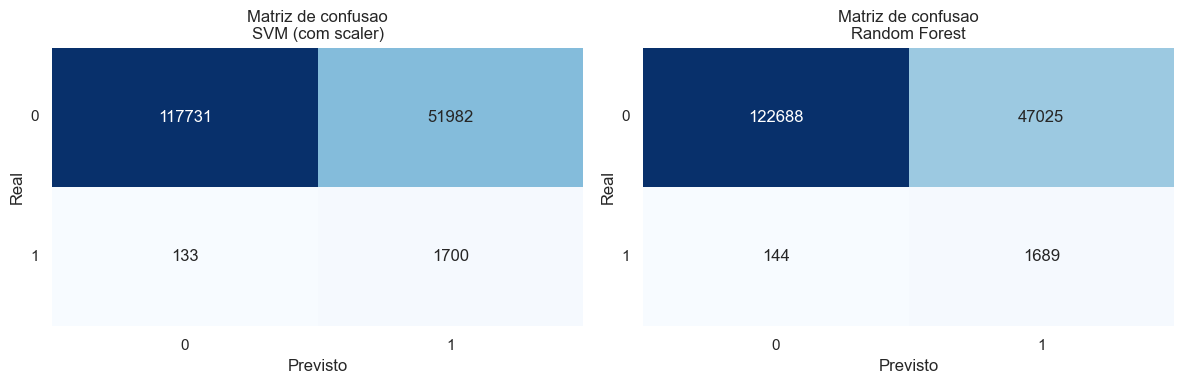

In [23]:
display(svm_tuning_df.head(10))
display(rf_tuning_df.head(10))

resultados_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}',
}).highlight_max(subset=['Recall'], color='#d9ead3')

fig, axes = plt.subplots(1, len(matrizes), figsize=(12, 4))
if len(matrizes) == 1:
    axes = [axes]

for ax, (nome, matriz) in zip(axes, matrizes.items()):
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Matriz de confusao\n{nome}')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
    ax.set_xticklabels(['0', '1'])
    ax.set_yticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.show()

#### Conclusão da Parte 3

- O `SVM` foi treinado dentro de `Pipeline` com `StandardScaler`, etapa essencial para modelos baseados em distância/margem.
- O `Random Forest` foi treinado como alternativa robusta baseada em árvores, menos sensível a escala.
- Foi realizado **tuning leve** com `GridSearchCV` para os dois modelos, usando grade pequena e `recall` como métrica principal.
- A comparação final no conjunto de teste permite escolher o modelo mais aderente ao objetivo do projeto.
- Em cenário de saúde, a prioridade continua sendo reduzir falsos negativos; por isso, `recall` é o critério central da decisão.

---

# Seção: `trabalho_parte_4.ipynb`

Origem: `ia_tech_challenge_01/trabalho_parte_4.ipynb`

### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs

#### Parte 4 - Classificação supervisionada: detecção de indícios de câncer de mama

Este notebook implementa a etapa de classificação supervisionada usando a base tratada do DATASUS (SIH/SUS RJ 2025).
O objetivo é criar um target binário a partir de `CANCER_MAMA_NIVEL > 0`, preparar os dados com `Pipeline` e `ColumnTransformer` e comparar um baseline ingênuo, uma regressão logística e um KNN.

## Sumário da Parte 4

#### Item 1 - Definição do target
#### Item 2 - Preparação dos dados
#### Item 3 - Separação entre treino e teste
#### Item 4 - Pipeline e treinamento dos modelos
#### Item 5 - Avaliação dos modelos
#### Item 6 - Comparação dos resultados
#### Item 7 - Validação cruzada
#### Item 8 - ROC e AUC
#### Conclusão da Parte 4


#### Item 1 - Definição do target

Vamos criar a variável binária `TARGET`: 0 significa sem indício e 1 significa com indício de câncer de mama.

Arquivo localizado em: /home/visheuleer/Desktop/Post-graduate/ia_tech_challenge_01/2025_tratado.parquet
Dimensões da base tratada: (857726, 76)
Distribuição do target:
TARGET
0    848560
1      9166
Name: count, dtype: int64

Proporção do target:
TARGET
0    0.989314
1    0.010686
Name: proporcao, dtype: float64


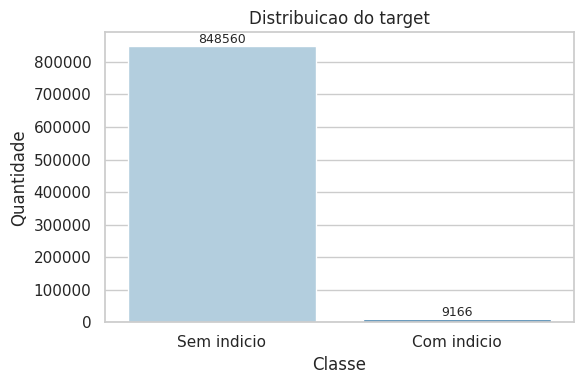

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

candidate_paths = [
    Path('2025_tratado.parquet'),
    Path('ia_tech_challenge_01/2025_tratado.parquet'),
    Path('/content/2025_tratado.parquet'),
    Path('/content/drive/MyDrive/2025_tratado.parquet'),
    Path('/content/drive/MyDrive/ia_tech_challenge_01/2025_tratado.parquet'),
]

path = next((candidate for candidate in candidate_paths if candidate.exists()), None)
if path is None:
    searched = '\n'.join(f'- {candidate}' for candidate in candidate_paths)
    raise FileNotFoundError(
        'Arquivo de base tratada não encontrado. Verifique onde o arquivo '
        "'2025_tratado.parquet' foi salvo e ajuste o caminho na célula.\n"
        f'Caminhos verificados:\n{searched}'
    )

print(f'Arquivo localizado em: {path.resolve()}')
dados = pd.read_parquet(path)
TARGET = 'TARGET'
dados[TARGET] = (dados['CANCER_MAMA_NIVEL'] > 0).astype(int)

print('Dimensões da base tratada:', dados.shape)
print('Distribuição do target:')
print(dados[TARGET].value_counts().sort_index())
print('\nProporção do target:')
print(dados[TARGET].value_counts(normalize=True).sort_index().rename('proporcao'))

target_plot = dados[TARGET].value_counts().sort_index().rename_axis('Classe').reset_index(name='Quantidade')
target_plot['Classe'] = target_plot['Classe'].map({0: 'Sem indicio', 1: 'Com indicio'})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=target_plot, x='Classe', y='Quantidade', hue='Classe', palette='Blues', legend=False)
ax.set_title('Distribuicao do target')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade')
for patch in ax.patches:
    ax.annotate(f"{int(patch.get_height())}", (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


#### Item 2 - Preparação dos dados

A seleção de variáveis prioriza atributos demográficos, administrativos e de utilização hospitalar.
Variáveis diretamente derivadas de diagnóstico foram evitadas para reduzir vazamento de target.

In [13]:
feature_candidates = [
    'IDADE_ANOS',
    'DIAS_PERM',
    'QT_DIARIAS',
    'UTI_MES_IN',
    'UTI_MES_AN',
    'UTI_MES_AL',
    'UTI_MES_TO',
    'UTI_INT_IN',
    'UTI_INT_AN',
    'UTI_INT_AL',
    'UTI_INT_TO',
    'DIAR_ACOM',
    'SEXO',
    'RACA_COR',
    'GESTRISCO',
    'CONTRACEP1',
    'CONTRACEP2',
    'PROC_REA'
]

leakage_columns = [
    'CANCER_MAMA_NIVEL',
    'DIAG_PRINC',
    'DIAGSEC1',
    'DIAGSEC2',
    'DIAGSEC3',
    'DIAGSEC4',
    'DIAGSEC5',
    'DIAGSEC6',
    'DIAGSEC7',
    'CID_MORTE',
    'DIAG_PRINC_GRUPO'
]

features = [col for col in feature_candidates if col in dados.columns]
leakage_present = [col for col in leakage_columns if col in dados.columns]

print('Features selecionadas para modelagem:')
print(features)
print('\nColunas sensíveis identificadas e excluídas da modelagem:')
print(leakage_present)


Features selecionadas para modelagem:
['IDADE_ANOS', 'DIAS_PERM', 'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO', 'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'DIAR_ACOM', 'SEXO', 'RACA_COR', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2', 'PROC_REA']

Colunas sensíveis identificadas e excluídas da modelagem:
['CANCER_MAMA_NIVEL', 'DIAG_PRINC', 'DIAGSEC1', 'DIAGSEC2', 'DIAGSEC3', 'DIAGSEC4', 'DIAGSEC5', 'DIAGSEC6', 'DIAGSEC7', 'CID_MORTE', 'DIAG_PRINC_GRUPO']


In [14]:
numerical_features = [col for col in features if dados[col].dtype.kind in 'biufc']
categorical_features = [col for col in features if col not in numerical_features]

if not numerical_features and not categorical_features:
    raise ValueError('Nenhuma feature válida foi encontrada para modelagem.')

# Limita o one-hot a colunas com cardinalidade controlada para evitar estouro de memória no Colab.
low_cardinality_features = []
high_cardinality_features = []

for col in categorical_features:
    nunique = dados[col].nunique(dropna=False)
    if nunique <= 20:
        low_cardinality_features.append(col)
    else:
        high_cardinality_features.append(col)

selected_features = numerical_features + low_cardinality_features
X = dados[selected_features].copy()
y = dados[TARGET].copy()

print('Features numéricas:', numerical_features)
print('Features categóricas de baixa cardinalidade:', low_cardinality_features)
print('Features categóricas excluídas por alta cardinalidade:', high_cardinality_features)
print('\nDimensões de X e y:', X.shape, y.shape)
print('\nValores ausentes por coluna:')
print(X.isna().sum().sort_values(ascending=False))


Features numéricas: ['IDADE_ANOS', 'DIAS_PERM', 'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO', 'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'DIAR_ACOM']
Features categóricas de baixa cardinalidade: ['SEXO', 'RACA_COR', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2']
Features categóricas excluídas por alta cardinalidade: ['PROC_REA']

Dimensões de X e y: (857726, 17) (857726,)

Valores ausentes por coluna:
IDADE_ANOS    0
DIAS_PERM     0
QT_DIARIAS    0
UTI_MES_IN    0
UTI_MES_AN    0
UTI_MES_AL    0
UTI_MES_TO    0
UTI_INT_IN    0
UTI_INT_AN    0
UTI_INT_AL    0
UTI_INT_TO    0
DIAR_ACOM     0
SEXO          0
RACA_COR      0
GESTRISCO     0
CONTRACEP1    0
CONTRACEP2    0
dtype: int64


#### Item 3 - Separação entre treino e teste

Usamos `train_test_split` com `stratify=y` para preservar a proporção de classes entre treino e teste.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Treino:', X_train.shape, 'Teste:', X_test.shape)
print('\nProporção de classes no treino:')
print(y_train.value_counts(normalize=True).sort_index())
print('\nProporção de classes no teste:')
print(y_test.value_counts(normalize=True).sort_index())


Treino: (686180, 17) Teste: (171546, 17)

Proporção de classes no treino:
TARGET
0    0.989313
1    0.010687
Name: proportion, dtype: float64

Proporção de classes no teste:
TARGET
0    0.989315
1    0.010685
Name: proportion, dtype: float64


#### Item 4 - Pipeline e treinamento dos modelos

As variáveis numéricas recebem imputação pela mediana e padronização com `StandardScaler`.
As categóricas de baixa cardinalidade recebem imputação e `OneHotEncoder`.

Serão comparados três modelos:
- `LogisticRegression` como baseline, com `class_weight='balanced'`
- `KNeighborsClassifier` como modelo principal, com ajuste simples de `k`
- `RandomForestClassifier` como alternativa baseada em árvores

Para os modelos probabilísticos, o `threshold` será definido a partir do conjunto de validação usando a curva de `precision-recall`, em vez de escolha manual.

In [ ]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_recall_curve, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, low_cardinality_features),
])

X_fit_log, X_val_log, y_fit_log, y_val_log = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

X_train_knn, _, y_train_knn, _ = train_test_split(
    X_train,
    y_train,
    train_size=min(100_000, len(X_train)),
    random_state=42,
    stratify=y_train,
)

X_fit_knn, X_val_knn, y_fit_knn, y_val_knn = train_test_split(
    X_train_knn,
    y_train_knn,
    test_size=0.2,
    random_state=42,
    stratify=y_train_knn,
)

print('Amostra de treino para KNN:', X_train_knn.shape)

def calcular_metricas_por_threshold(y_true, y_scores):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    rows = []
    for threshold, precision, recall, f1 in zip(thresholds, precisions[:-1], recalls[:-1], f1_scores):
        rows.append({
            'Threshold': float(threshold),
            'Precision': float(precision),
            'Recall': float(recall),
            'F1': float(f1),
        })
    return pd.DataFrame(rows)

def selecionar_threshold_por_precision_com_recall_alto(metricas_threshold, recall_minimo=0.75):
    candidatos = metricas_threshold[metricas_threshold['Recall'] >= recall_minimo].copy()

    if candidatos.empty:
        candidatos = metricas_threshold.copy()
        print(
            f"Nenhum threshold atingiu recall mínimo de {recall_minimo:.2f}. "
            "Usando o melhor recall disponível."
        )

        candidatos = candidatos.sort_values(
            by=['Recall', 'Precision', 'F1'],
            ascending=[False, False, False]
        )
    else:
        candidatos = candidatos.sort_values(
            by=['Precision', 'Recall', 'F1'],
            ascending=[False, False, False]
        )

    linha = candidatos.iloc[0]

    return (
        float(linha['Threshold']),
        float(linha['Precision']),
        float(linha['Recall']),
        float(linha['F1'])
    )

tuning_rows = []
threshold_rows = []
model_configs = {}

logistic_validation_model = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])
logistic_validation_model.fit(X_fit_log, y_fit_log)
val_scores_log = logistic_validation_model.predict_proba(X_val_log)[:, 1]
log_threshold_df = calcular_metricas_por_threshold(y_val_log, val_scores_log)
log_threshold_df['Modelo'] = 'Baseline (Logistic Regression)'
threshold_rows.extend(log_threshold_df.to_dict(orient='records'))
best_threshold_log, best_precision_log, best_recall_log, best_f1_log = selecionar_threshold_por_precision_com_recall_alto(
    log_threshold_df,
    recall_minimo=0.75
)
tuning_rows.append({
    'Modelo': 'Baseline (Logistic Regression)',
    'Parametro': f'threshold={best_threshold_log:.4f}',
    'Precision': best_precision_log,
    'Recall': best_recall_log,
    'F1': best_f1_log,
})
print(f'Melhor threshold para Logistic Regression: {best_threshold_log:.4f}')

model_configs['Baseline (Logistic Regression)'] = {
    'pipeline': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ]),
    'threshold': best_threshold_log,
}
model_configs['Baseline (Logistic Regression)']['pipeline'].fit(X_train, y_train)
print('Baseline (Logistic Regression) treinado com sucesso')

best_k = None
best_knn_metrics = None
for k in [3, 5, 9, 15]:
    knn_validation_model = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', KNeighborsClassifier(n_neighbors=k)),
    ])
    knn_validation_model.fit(X_fit_knn, y_fit_knn)
    y_val_pred = knn_validation_model.predict(X_val_knn)
    precision = precision_score(y_val_knn, y_val_pred, zero_division=0)
    recall = recall_score(y_val_knn, y_val_pred, zero_division=0)
    f1 = f1_score(y_val_knn, y_val_pred, zero_division=0)
    tuning_rows.append({
        'Modelo': 'KNN',
        'Parametro': f'k={k}',
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
    })
    current_metrics = (f1, recall, precision)
    if best_knn_metrics is None or current_metrics > best_knn_metrics:
        best_knn_metrics = current_metrics
        best_k = k

print(f'Melhor valor de k para KNN: {best_k}')

model_configs['KNN'] = {
    'pipeline': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', KNeighborsClassifier(n_neighbors=best_k)),
    ]),
    'threshold': None,
}
model_configs['KNN']['pipeline'].fit(X_train_knn, y_train_knn)
print('KNN treinado com sucesso em amostra estratificada do treino')

rf_validation_model = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    )),
])
rf_validation_model.fit(X_fit_log, y_fit_log)
val_scores_rf = rf_validation_model.predict_proba(X_val_log)[:, 1]
rf_threshold_df = calcular_metricas_por_threshold(y_val_log, val_scores_rf)
rf_threshold_df['Modelo'] = 'Random Forest'
threshold_rows.extend(rf_threshold_df.to_dict(orient='records'))
best_threshold_rf, best_precision_rf, best_recall_rf, best_f1_rf = selecionar_threshold_por_precision_com_recall_alto(
    rf_threshold_df,
    recall_minimo=0.75
)
tuning_rows.append({
    'Modelo': 'Random Forest',
    'Parametro': f'threshold={best_threshold_rf:.4f}',
    'Precision': best_precision_rf,
    'Recall': best_recall_rf,
    'F1': best_f1_rf,
})
print(f'Melhor threshold para Random Forest: {best_threshold_rf:.4f}')

model_configs['Random Forest'] = {
    'pipeline': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=10,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    'threshold': best_threshold_rf,
}
model_configs['Random Forest']['pipeline'].fit(X_train, y_train)
print('Random Forest treinado com sucesso')

tuning_df = pd.DataFrame(tuning_rows)
threshold_df = pd.DataFrame(threshold_rows)
tuning_df.sort_values(by=['Modelo', 'F1', 'Recall'], ascending=[True, False, False]).reset_index(drop=True)


Amostra de treino para KNN: (100000, 17)
Melhor threshold para Logistic Regression: 0.6314
Baseline (Logistic Regression) treinado com sucesso
Melhor valor de k para KNN: 3
KNN treinado com sucesso em amostra estratificada do treino
Melhor threshold para Random Forest: 0.6506
Random Forest treinado com sucesso


,Modelo,Parametro,Precision,Recall,F1
0,Baseline (Logistic Regression),threshold=0.6314,0.037197,0.752556,0.070890
1,KNN,k=3,0.038462,0.004673,0.008333
2,KNN,k=5,0.000000,0.000000,0.000000
3,KNN,k=9,0.000000,0.000000,0.000000
4,KNN,k=15,0.000000,0.000000,0.000000
5,Random Forest,threshold=0.6506,0.053230,0.750511,0.099409


## Item 5 - Avaliação dos Modelos

Agora chegamos na parte mais importante: colocar os modelos à prova no conjunto de teste.

Aqui calculamos as seguintes métricas para cada modelo:
- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusão

Antes de analisar os números, é essencial entender o que cada métrica realmente representa, especialmente porque, neste problema que estamos tratando, nem todas têm o mesmo peso.

---

### Accuracy
A **accuracy** mostra o percentual total de acertos.

O problema é que ela pode ser enganosa em bases desbalanceadas como a nossa.  
Um modelo que previsse *"sem indício"* para todos os casos acertaria quase 99% e mesmo assim seria completamente inútil.

---

### Precision
A **precision** responde à seguinte pergunta:

> Dos registros que o modelo marcou como positivos, quantos realmente eram positivos?

Uma precision baixa indica que o modelo está gerando muitos **falsos positivos** (alarmes falsos).

---

### Recall (Métrica mais importante pro nosso problema)
O **recall** responde:

> Dos casos que realmente tinham indício, quantos o modelo conseguiu identificar?

Essa é a métrica mais crítica neste contexto. Deixar escapar um caso real (**falso negativo**) é muito mais grave, isso porque um falso positivo pode ser investigado posteriormente, já o caso ignorado pode não ter uma segunda chance ou ser tarde demais.

---

### F1-score
O **F1-score** é a média harmônica entre precision e recall.

Ele é útil quando queremos equilibrar os dois tipos de erro sem priorizar apenas um lado.

---

### Critério de Avaliação

Pelos motivos explicados acima, a tabela de resultados está ordenada por:

1. Recall (principal critério)
2. Demais métricas como apoio

O recall é o que melhor indica qual modelo seria mais útil em um cenário real de triagem de saúde.

---

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

results = []
confusion_matrices = {}

for name, config in model_configs.items():
    pipeline = config['pipeline']
    threshold = config['threshold']

    if threshold is None:
        y_pred = pipeline.predict(X_test)
    else:
        y_scores = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)

    matriz = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    confusion_matrices[name] = matriz

    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Configuracao': f'threshold={threshold:.2f}' if threshold is not None else f'k={best_k}',
    })

    print(f'--- {name} ---')
    if threshold is not None:
        print(f'Threshold aplicado: {threshold:.2f}')
    else:
        print(f'Valor de k aplicado: {best_k}')
    print(classification_report(y_test, y_pred, zero_division=0))
    print('Matriz de confusão:')
    print(pd.DataFrame(matriz, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))
    print()

results_df = pd.DataFrame(results).set_index('Modelo')
results_df = results_df.sort_values(by=['Recall', 'F1', 'Precision'], ascending=False)
results_df.round(4)


--- Baseline (Logistic Regression) ---
Threshold aplicado: 0.63
              precision    recall  f1-score   support

           0       1.00      0.79      0.88    169713
           1       0.04      0.74      0.07      1833

    accuracy                           0.79    171546
   macro avg       0.52      0.77      0.47    171546
weighted avg       0.99      0.79      0.87    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  133780   35933
Real 1     470    1363

--- KNN ---
Valor de k aplicado: 3
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    169713
           1       0.13      0.02      0.04      1833

    accuracy                           0.99    171546
   macro avg       0.56      0.51      0.51    171546
weighted avg       0.98      0.99      0.98    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  169449     264
Real 1    1795      38

--- Random Forest ---
Threshold aplicado: 0.65
              precis

,Accuracy,Precision,Recall,F1,Configuracao
Modelo,,,,,
Random Forest,0.8432,0.0508,0.7741,0.0954,threshold=0.65
Baseline (Logistic Regression),0.7878,0.0365,0.7436,0.0697,threshold=0.63
KNN,0.9880,0.1258,0.0207,0.0356,k=3


O primeiro ponto que chama atenção é a accuracy do KNN: 98,8%. À primeira vista parece impressionante, mas olhando o recall de apenas 2,1%, fica claro que está acontecendo o que foi comentado na seção de critérios de avaliação: o modelo praticamente chuta tudo como negativo. Como a base é fortemente desbalanceada (a grande maioria dos registros é classe 0), ele acerta quase tudo simplesmente ignorando os casos positivos. É exatamente por isso que accuracy sozinha não diz nada neste tipo de problema.

A Regressão Logística apresentou recall de 74,4% dos casos positivos reais identificados corretamente. Ela paga um preço por isso, a accuracy cai para 78,8% e a precision fica bem baixa 3,6%, o que significa que ela gera bastante falso positivo. Mas no contexto de triagem de saúde, identificar quase 3 de cada 4 casos reais é muito mais valioso do que ter uma accuracy alta sem detectar ninguém.

O Random Forest apresentou o melhor recall: 77,4%, com precision de 5,1% e F1 de 0.0954, o melhor F1 dos três. Ele é mais equilibrado entre os dois tipos de erro, pois detecta mais casos positivos do que a Regressão Logística e ainda mantém uma precision um pouco melhor.

Olhando as matrizes de confusão, isso fica ainda mais claro. A Regressão Logística capturou 1.363 verdadeiros positivos de um total de 1.833 casos reais. O Random Forest capturou 1.419. O KNN capturou somente 38.

Em resumo: Nosso objetivo é uma triagem que não deixe casos passarem, portanto, o Random Forest é a escolha mais adequada dos três, pois apresentou o maior recall e o melhor F1 entre os modelos avaliados.

---

#### Item 6 - Comparação dos resultados

As tabelas abaixo resumem o ajuste dos hiperparâmetros e a comparação final dos modelos. A escolha do threshold foi feita via validação com curva de `precision-recall`.

,Modelo,Parametro,Precision,Recall,F1
0,Baseline (Logistic Regression),threshold=0.6314,0.037197,0.752556,0.070890
1,KNN,k=3,0.038462,0.004673,0.008333
2,KNN,k=5,0.000000,0.000000,0.000000
3,KNN,k=9,0.000000,0.000000,0.000000
4,KNN,k=15,0.000000,0.000000,0.000000
5,Random Forest,threshold=0.6506,0.053230,0.750511,0.099409


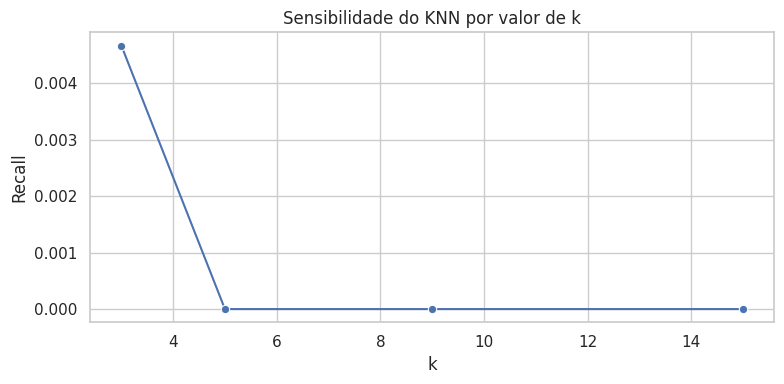

,Threshold,Precision,Recall,F1
33525,0.5000,0.0324,0.9100,0.0626
33526,0.5000,0.0324,0.9100,0.0626
33527,0.5000,0.0324,0.9100,0.0626
34778,0.5500,0.0349,0.8725,0.0672
34779,0.5500,0.0349,0.8725,0.0672
34780,0.5500,0.0349,0.8725,0.0672
34781,0.5500,0.0349,0.8725,0.0672
35554,0.5800,0.0358,0.8337,0.0687
36098,0.6000,0.0363,0.8064,0.0696
37012,0.6314,0.0372,0.7526,0.0709


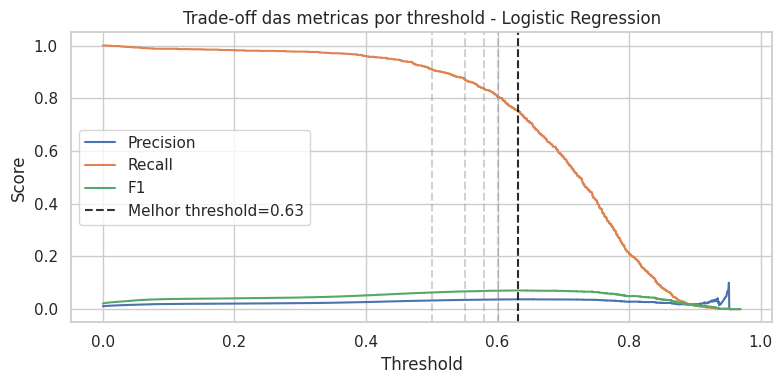

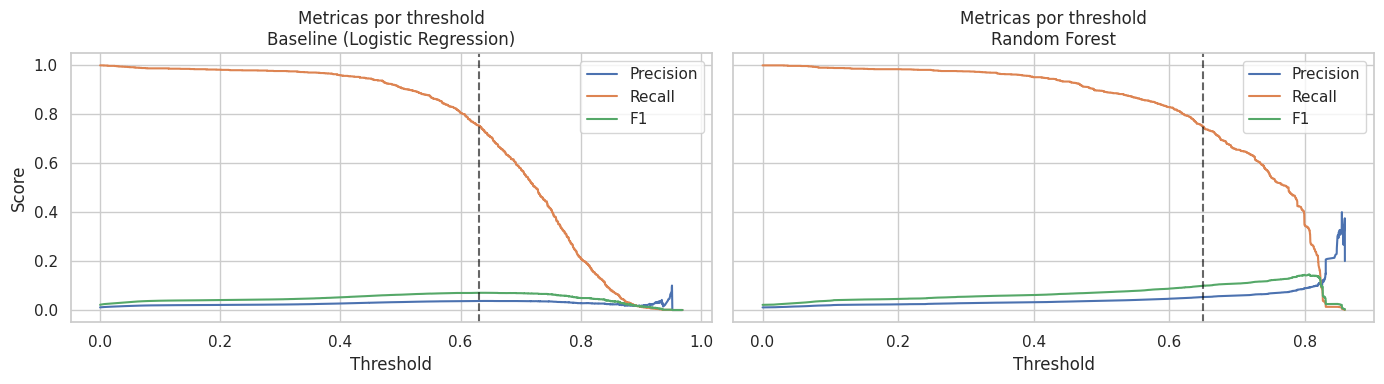

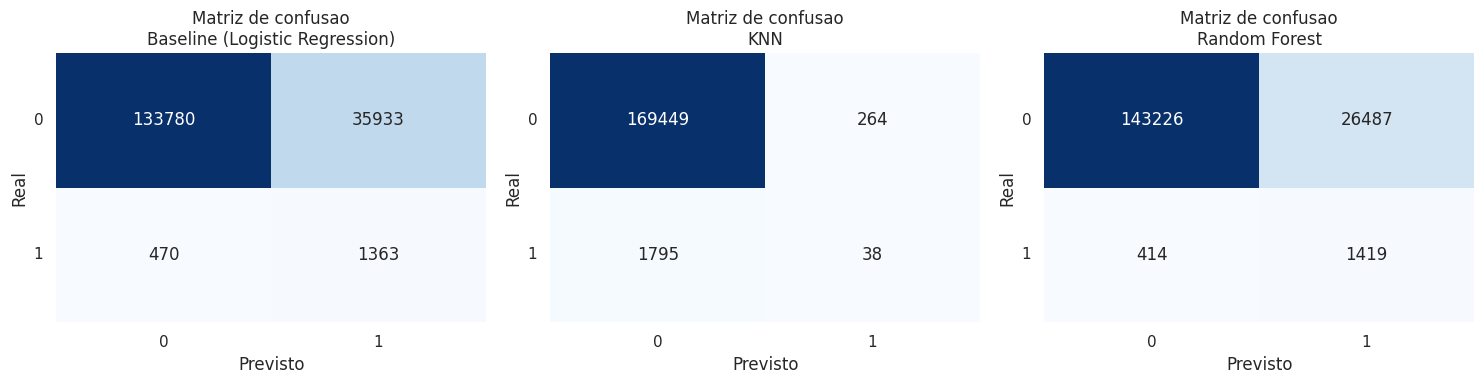

In [18]:
display(tuning_df.sort_values(by=['Modelo', 'F1', 'Recall'], ascending=[True, False, False]).reset_index(drop=True))

comparison = results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'Configuracao']].copy()
comparison.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}',
}).highlight_max(subset=['Recall'], color='#d9ead3')

plt.figure(figsize=(8, 4))
tuning_plot = tuning_df.copy()
tuning_plot['Valor'] = tuning_plot['Parametro'].str.extract(r'([0-9.]+)$').astype(float)
ax = sns.lineplot(data=tuning_plot[tuning_plot['Modelo'] == 'KNN'], x='Valor', y='Recall', marker='o')
ax.set_title('Sensibilidade do KNN por valor de k')
ax.set_xlabel('k')
ax.set_ylabel('Recall')
plt.tight_layout()
plt.show()

threshold_plot_df = threshold_df.copy()
threshold_plot_df = threshold_plot_df[(threshold_plot_df['Threshold'] >= 0.0) & (threshold_plot_df['Threshold'] <= 1.0)]

logistic_threshold_reference = [0.50, 0.55, 0.58, 0.60, round(best_threshold_log, 4)]
logistic_threshold_table = threshold_plot_df[threshold_plot_df['Modelo'] == 'Baseline (Logistic Regression)'].copy()
logistic_threshold_table['ThresholdRound'] = logistic_threshold_table['Threshold'].round(4)
logistic_threshold_table = logistic_threshold_table[logistic_threshold_table['ThresholdRound'].isin(logistic_threshold_reference)]
logistic_threshold_table = logistic_threshold_table[['ThresholdRound', 'Precision', 'Recall', 'F1']].drop_duplicates().sort_values('ThresholdRound')
display(logistic_threshold_table.rename(columns={'ThresholdRound': 'Threshold'}).round(4))

plt.figure(figsize=(8, 4))
df_logistic = threshold_plot_df[threshold_plot_df['Modelo'] == 'Baseline (Logistic Regression)'].sort_values('Threshold')
sns.lineplot(data=df_logistic, x='Threshold', y='Precision', label='Precision')
sns.lineplot(data=df_logistic, x='Threshold', y='Recall', label='Recall')
sns.lineplot(data=df_logistic, x='Threshold', y='F1', label='F1')
for ref in logistic_threshold_reference:
    plt.axvline(ref, linestyle='--', color='gray', alpha=0.35)
plt.axvline(best_threshold_log, linestyle='--', color='black', alpha=0.8, label=f'Melhor threshold={best_threshold_log:.2f}')
plt.title('Trade-off das metricas por threshold - Logistic Regression')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, model_name in zip(axes, ['Baseline (Logistic Regression)', 'Random Forest']):
    df_model = threshold_plot_df[threshold_plot_df['Modelo'] == model_name].sort_values('Threshold')
    sns.lineplot(data=df_model, x='Threshold', y='Precision', ax=ax, label='Precision')
    sns.lineplot(data=df_model, x='Threshold', y='Recall', ax=ax, label='Recall')
    sns.lineplot(data=df_model, x='Threshold', y='F1', ax=ax, label='F1')
    melhor = tuning_df[tuning_df['Modelo'] == model_name].iloc[0]
    valor_threshold = float(melhor['Parametro'].split('=')[1])
    ax.axvline(valor_threshold, linestyle='--', color='black', alpha=0.6)
    ax.set_title(f'Metricas por threshold\n{model_name}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(confusion_matrices), figsize=(15, 4))
if len(confusion_matrices) == 1:
    axes = [axes]
for ax, (name, matriz) in zip(axes, confusion_matrices.items()):
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Matriz de confusao\n{name}')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
    ax.set_xticklabels(['0', '1'])
    ax.set_yticklabels(['0', '1'], rotation=0)
plt.tight_layout()
plt.show()


Os gráficos de threshold nos ajudam a entender por que cada modelo chegou nos números que chegou.

### KNN
O gráfico de sensibilidade mostra que o recall despenca rapidamente conforme k aumenta. Com k=3, o recall já é muito baixo, apenas 2,1%, o modelo praticamente não consegue capturar os positivos dessa base. Para valores maiores de k, o desempenho tende a piorar ainda mais. Isso confirma que o KNN não é adequado aqui.

---

### Regressão Logística
O threshold ótimo foi 0,63. No gráfico, dá para ver claramente o trade-off: abaixo de 0,63, o recall é mais alto, mas a precision continua muito baixa. Acima de 0,63, a precision sobe um pouco, mas o recall começa a cair. O ponto escolhido mantém um recall alto, de 74,4%, com precision de 3,65%. Vale notar que mesmo assim a precision continua muito baixa, o que reflete o desbalanceamento severo da base: o modelo precisa gerar muitos alertas para capturar os positivos reais.

---

### Random Forest
O threshold ótimo foi 65%. Nesse ponto, ele apresentou o melhor recall entre os três modelos, com 77,41%, além de uma precision de 5,08% e F1 de 9,54%. Isso significa que ele conseguiu capturar mais positivos que a Regressão Logística e, ao mesmo tempo, manteve uma precision ligeiramente melhor. Por isso, ele aparece como o modelo mais equilibrado nesta comparação.

---

### Matrizes de confusão
Nas matrizes de confusão, o contraste entre os modelos é direto:

- **Regressão Logística:** 1.363 verdadeiros positivos, mas também muitos falsos positivos.  
- **Random Forest:** 1.419 verdadeiros positivos, com melhor equilíbrio entre recall e precision.
- **KNN:** apenas 38 verdadeiros positivos, o que torna ele sem utilidade para o objetivo.

---

Cada modelo representa uma escolha diferente nesse trade-off. A Regressão Logística detecta muitos casos positivos, mas gera muitos alertas. O Random Forest consegue detectar ainda mais positivos e apresenta o melhor F1. O KNN não serve para este problema.

---

#### Item 7 - Validação cruzada

Para alinhar a análise com o conteúdo de validação cruzada estudado na pós, vamos comparar os modelos usando `cross_val_score` com foco em `recall`.


In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_rows = []

cv_models = {
    'Baseline (Logistic Regression)': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ]),
    'KNN': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', KNeighborsClassifier(n_neighbors=best_k)),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=10,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

for name, model in cv_models.items():
    X_cv = X_train_knn if name == 'KNN' else X_train
    y_cv = y_train_knn if name == 'KNN' else y_train
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='recall', n_jobs=1)
    cv_rows.append({
        'Modelo': name,
        'Recall CV Mean': scores.mean(),
        'Recall CV Std': scores.std(),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(by='Recall CV Mean', ascending=False)
cv_results_df.round(4)


,Modelo,Recall CV Mean,Recall CV Std
0,Baseline (Logistic Regression),0.9146,0.0083
2,Random Forest,0.8984,0.0029
1,KNN,0.0140,0.0046


### Regressão Logística

A Regressão Logística lidera com recall médio de 91,46% e desvio padrão de apenas 0,83%. Esse resultado mostra que o modelo é estável entre os folds. O modelo não está dependendo de um split específico para performar bem, ele consistentemente identifica a maioria dos positivos.

---

### Random Forest

O Random Forest fica próximo do modelo de regressão logística, com recall médio de 89,84% e o menor desvio padrão de todos (0,29%). É o modelo mais estável dos três, suas previsões variam menos conforme a composição do treino muda. Isso é uma qualidade importante em produção.

---

### KNN

O KNN segue com recall de apenas 1,40% na validação cruzada, confirmando que o desempenho fraco não foi acidente de um único split. O modelo genuinamente não consegue lidar com o desbalanceamento desta base.

---

Um detalhe importante é que os recalls da validação cruzada ficaram maiores do que os recalls observados no conjunto de teste. A Regressão Logística teve recall médio de 91,46% na validação cruzada, enquanto o Random Forest ficou próximo, com 89,84%. No teste final, porém, o Random Forest apresentou o melhor resultado, com recall de 77,41%, contra 74,36% da Regressão Logística. Isso mostra que os dois modelos têm boa capacidade de identificar positivos.

---

#### Item 8 - ROC e AUC

Como visto na aula de ROC/AUC, modelos que retornam probabilidade podem ser comparados pela capacidade de ranquear corretamente as classes. Aqui vamos comparar `Logistic Regression` e `Random Forest`.


--- Baseline (Logistic Regression) ---
AUC: 0.8362
--- Random Forest ---
AUC: 0.8962


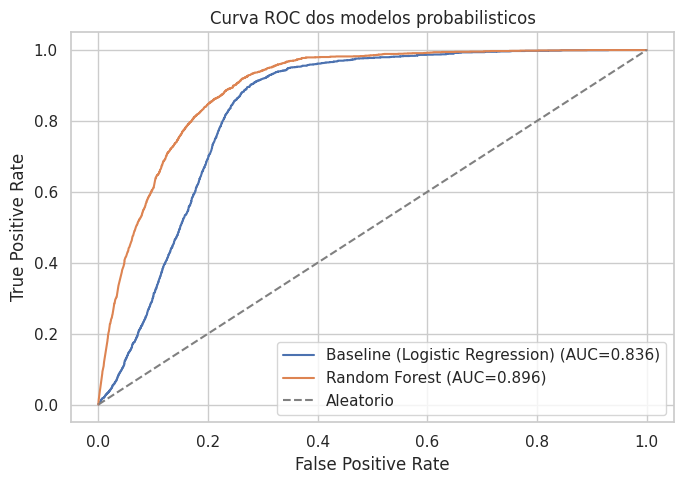

In [22]:
from sklearn.metrics import auc, roc_curve

roc_rows = []
roc_curves = {}

for name in ['Baseline (Logistic Regression)', 'Random Forest']:
    pipeline = model_configs[name]['pipeline']
    y_scores = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    roc_curves[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}
    roc_rows.append({
        'Modelo': name,
        'AUC': roc_auc,
    })
    print(f'--- {name} ---')
    print(f'AUC: {roc_auc:.4f}')

roc_results_df = pd.DataFrame(roc_rows).sort_values(by='AUC', ascending=False)
roc_results_df.round(4)

plt.figure(figsize=(7, 5))
for name, values in roc_curves.items():
    plt.plot(values['fpr'], values['tpr'], label=f"{name} (AUC={values['auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatorio')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC dos modelos probabilisticos')
plt.legend()
plt.tight_layout()
plt.show()


#### Conclusão da Parte 4

A avaliação dos modelos mostrou que, neste problema, não faz sentido olhar apenas para a accuracy. Como a base é muito desbalanceada, um modelo pode ter uma taxa alta de acerto simplesmente por classificar quase todos os registros como negativos. Foi exatamente o que aconteceu com o KNN: apesar de atingir 98,80% de accuracy, ele teve recall de apenas 2,07%, identificando somente 38 dos 1.833 casos positivos reais. Por esse motivo, ele não se mostrou adequado para uma aplicação de triagem.

A Regressão Logística e o Random Forest apresentaram resultados mais coerentes com o objetivo do trabalho. A Regressão Logística conseguiu identificar 74,36% dos casos positivos no conjunto de teste e teve recall médio de 91,46% na validação cruzada. Esse resultado mostra que o modelo tem boa capacidade de capturar casos positivos, embora ainda gere muitos falsos positivos, como indica sua precision de 3,65%.

O Random Forest teve o melhor desempenho geral no conjunto de teste. Ele alcançou recall de 77,41%, precision de 5,08% e F1 de 9,54%, capturando 1.419 dos 1.833 casos positivos reais. Além disso, também apresentou a maior AUC, com 89,62%, indicando melhor capacidade de separar casos positivos e negativos ao longo dos diferentes thresholds. Na validação cruzada, seu recall médio foi de 89,84%, muito próximo ao da Regressão Logística, mas com menor desvio padrão (0,29%), o que sugere um comportamento mais estável entre os folds.

Assim, considerando o objetivo do problema, o Random Forest foi o modelo mais adequado entre os avaliados. Ele conseguiu manter um recall alto, apresentou melhor precision, melhor F1 e maior AUC. A baixa precision ainda é um ponto de atenção, mas já era esperada por causa do forte desbalanceamento da base e do foco em reduzir falsos negativos.

Por fim, o ajuste de threshold teve papel importante nos resultados. Em um problema de saúde, especialmente em triagem, o custo de deixar passar um possível caso positivo é maior do que o de gerar um falso positivo. Por isso, a escolha do ponto de corte precisa levar em conta esse contexto, priorizando configurações que aumentem a capacidade de detectar os casos positivos.